In [1]:
import tensorflow as tf
import keras
from keras import layers
import pickle
import numpy as np
import pandas as pd
from keras.models import load_model

from scipy.stats import norm
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, anderson, wasserstein_distance
from sklearn.metrics import r2_score
import glob

import warnings
warnings.filterwarnings("ignore")

In [2]:
lat = np.arange(-90, 90, 180/192)
lon = np.arange(0, 360, 360/288)

lat_bnd1 = np.where(lat==10.3125)[0][0]
lat_bnd2 = np.where(lat==50.625)[0][0]
lon_bnd1 = np.where(lon==210)[0][0]
lon_bnd2 = np.where(lon==300)[0][0]

## ERA5 Data

In [3]:
#set the base path 
base_path = '/sfs/weka/scratch/zkq5md'

#load the dataframe
df_se_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/SE_detrend_precip.csv', index_col='Unnamed: 0')
df_gp_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/GP_detrend_precip.csv', index_col='Unnamed: 0')
df_ca_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/CA_detrend_precip.csv', index_col='Unnamed: 0')
df_se_era5

,Datetimes,Maximum Precipitation,lats,lons
0,1950-01-01,29.729749,32.8125,266.25
1,1950-01-02,39.121912,35.6250,270.00
2,1950-01-03,18.399313,35.6250,266.25
3,1950-01-04,59.563390,35.6250,267.50
4,1950-01-05,40.699897,35.6250,271.25
...,...,...,...,...
9977,2015-12-27,75.272000,34.6875,266.25
9978,2015-12-28,51.817838,35.6250,267.50
9979,2015-12-29,26.021470,34.6875,276.25
9980,2015-12-30,44.338429,30.9375,271.25


In [4]:
with open(f'{base_path}/Data/ERA5/Final/X_era5.pkl', "rb") as f:
    x = pickle.load(f)
    
x = np.transpose(np.array(x), (0, 2, 3, 1))

x = x[:, lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2, :]

x_test_era5 = x[8000:]

y_se_era5_test = df_se_era5['Maximum Precipitation'].values[8000:]
y_gp_era5_test = df_gp_era5['Maximum Precipitation'].values[8000:]
y_ca_era5_test = df_ca_era5['Maximum Precipitation'].values[8000:]



In [5]:
polyfit_se = pd.read_csv(f'{base_path}/Data/ERA5/Final/SE_poltfit.csv', index_col='Unnamed: 0')
polyfit_gp = pd.read_csv(f'{base_path}/Data/ERA5/Final/GP_poltfit.csv', index_col='Unnamed: 0')
polyfit_ca = pd.read_csv(f'{base_path}/Data/ERA5/Final/CA_poltfit.csv', index_col='Unnamed: 0')

## CESM Data

In [6]:
#set the base path 
base_path = '/sfs/weka/scratch/zkq5md'

with open(f"{base_path}/Full_Domain/X_test.pkl", "rb") as f:
    x_test_cesm = pickle.load(f)
    
x_test_cesm = x_test_cesm[:, lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2, :]
    
print(x_test_cesm.shape)

(22652, 43, 72, 3)


In [7]:
#the set the validata and testing members
val_num = 15
test_num = val_num +2

#set the range of member numbers
val_nums = np.arange(val_num,val_num+2,1)
test_nums = np.arange(test_num,test_num+2,1)

In [8]:
#load the dataframe
df_se_cesm = pd.read_csv(f'{base_path}/Full_Domain/SE_detrend_precip.csv', index_col='Unnamed: 0')
df_gp_cesm = pd.read_csv(f'{base_path}/Full_Domain/GP_detrend_precip.csv', index_col='Unnamed: 0')
df_ca_cesm = pd.read_csv(f'{base_path}/Full_Domain/CA_detrend_precip.csv', index_col='Unnamed: 0')

df_se_cesm=df_se_cesm[(df_se_cesm['Member'].isin(test_nums))].copy()
df_gp_cesm=df_gp_cesm[(df_gp_cesm['Member'].isin(test_nums))].copy()
df_ca_cesm=df_ca_cesm[(df_ca_cesm['Member'].isin(test_nums))].copy()

y_se_cesm_test = df_se_cesm['Maximum Precipitation'].values
y_gp_cesm_test = df_gp_cesm['Maximum Precipitation'].values
y_ca_cesm_test = df_ca_cesm['Maximum Precipitation'].values

df_se_cesm

,Datetimes,Member,Maximum Precipitation,lats,lons
181216,1940-01-01 00:00:00,17.0,46.601204,30.628272,280.00
181217,1940-01-02 00:00:00,17.0,8.604802,35.340314,278.75
181218,1940-01-03 00:00:00,17.0,53.491662,35.340314,276.25
181219,1940-01-04 00:00:00,17.0,41.651847,35.340314,276.25
181220,1940-01-05 00:00:00,17.0,16.084387,35.340314,276.25
...,...,...,...,...,...
203863,2014-12-28 00:00:00,18.0,12.462667,35.340314,266.25
203864,2014-12-29 00:00:00,18.0,9.678012,35.340314,272.50
203865,2014-12-30 00:00:00,18.0,39.065999,34.397906,277.50
203866,2014-12-31 00:00:00,18.0,18.523190,35.340314,280.00


In [9]:
se_polyfit = pd.read_csv(f'{base_path}/Full_Domain/SE_polyfit_slope_int.csv', index_col='Unnamed: 0')
gp_polyfit = pd.read_csv(f'{base_path}/Full_Domain/GP_polyfit_slope_int.csv', index_col='Unnamed: 0')
ca_polyfit = pd.read_csv(f'{base_path}/Full_Domain/CA_polyfit_slope_int.csv', index_col='Unnamed: 0')

## Average r-squared value

In [10]:
locs = ['se', 'gp', 'ca']
dirs = ['pre', 'pre', 'post', 'brute']
datasets = ['cesm', 'era5', 'era5', 'era5']
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']

rss = []
locss = []
dirss = []
datass = []
typess = []


for num1, direct in enumerate(dirs):
    
    for loc in locs:
        
        for model_type in model_types:
            
            model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/{direct}/{loc}_max_precip_{model_type}_model*')
            rs = []
            
            for model_path in model_list:
                
                if model_type == 'weight_mse' or model_type == 'line':
                    model = load_model(f"{model_path}", compile=False)
                    
                else:
                    model = load_model(f"{model_path}", safe_mode=False)
                    
                y_pred = model.predict(locals()[f'x_test_{datasets[num1]}'])
                rs.append(r2_score(locals()[f'y_{loc}_{datasets[num1]}_test'], y_pred))
                
            rss.append(np.average(rs))
            locss.append(loc)
            dirss.append(direct)
            datass.append(datasets[num1])
            typess.append(model_type)
                    


I0000 00:00:1770831323.523014   30012 service.cc:146] XLA service 0x7f956c008500 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770831323.523046   30012 service.cc:154]   StreamExecutor device (0): Host, Default Version


  5/708 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step   

I0000 00:00:1770831324.149451   30012 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


708/708 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
708/708 ━━━━━━━━━━━━━━━

In [11]:
df = pd.DataFrame({'r2': rss, 'location': locss, 'directory': dirss,
              'dataset': datass, 'model type': typess})
df

,r2,location,directory,dataset,model type
0,0.870107,se,pre,cesm,mse
1,0.830475,se,pre,cesm,weight_mse
2,0.865499,se,pre,cesm,weight_mae
3,0.657318,se,pre,cesm,line
4,0.834810,gp,pre,cesm,mse
5,0.788298,gp,pre,cesm,weight_mse
6,0.829549,gp,pre,cesm,weight_mae
7,0.539341,gp,pre,cesm,line
8,0.900133,ca,pre,cesm,mse
9,0.862837,ca,pre,cesm,weight_mse


## CDFs

In [12]:
locs = ['se', 'gp', 'ca']
dirs = ['pre', 'pre', 'post', 'brute']
datasets = ['cesm', 'era5', 'era5', 'era5']
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']

for num1, direct in enumerate(dirs):
    
    for num2, loc in enumerate(locs):

        for model_type in model_types:

            model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/{direct}/{loc}_max_precip_{model_type}_model*')

            for num3, model_path in enumerate(model_list):

                if model_type == 'weight_mse' or model_type == 'line':
                    model = load_model(f"{model_path}", compile=False)

                else:
                    model = load_model(f"{model_path}", safe_mode=False)

                locals()[f'y_pred{num3+1}'] = model.predict(locals()[f'x_test_{datasets[num1]}'], verbose=0).flatten()
            locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}'] = pd.DataFrame({'Y_max_test': locals()[f'y_{loc}_{datasets[num1]}_test'], 'y_pred1': y_pred1,
                                                                        'y_pred2': y_pred2, 'y_pred3': y_pred3, 'y_pred4': y_pred4,
                                                                        'y_pred5': y_pred5, 'y_pred6': y_pred6, 'y_pred7': y_pred7,
                                                                        'y_pred8': y_pred8, 'y_pred9': y_pred9, 'y_pred10': y_pred10})

In [13]:
def cesm_retrend(vals, poly):
    
    poly1 = np.arange(vals[0:int(vals.shape[0]/2)].shape[0])
    poly2 = np.arange(vals[0:int(vals.shape[0]/2)].shape[0])

    poly1 = poly.iloc[16].Member * poly1 + poly.iloc[16].Intercepts
    poly2 = poly.iloc[17].Member * poly2 + poly.iloc[17].Intercepts

    y1 = poly1 + vals[0:int(vals.shape[0]/2)]
    y2 = poly2 + vals[int(vals.shape[0]/2):]

    vals = np.concatenate(np.array([y1, y2]), axis=0)
    vals[vals < 0] = 0
    
    return vals

In [14]:
def era5_retrend(vals, poly):
    
    poly1 = np.arange(8000, 8000+vals[0:int(vals.shape[0])].shape[0], 1)
    poly1 = poly.iloc[0].Slopes * poly1 + poly.iloc[0].Intercept

    y = poly1 + vals[0:int(vals.shape[0])]

    y[y < 0] = 0

    return y

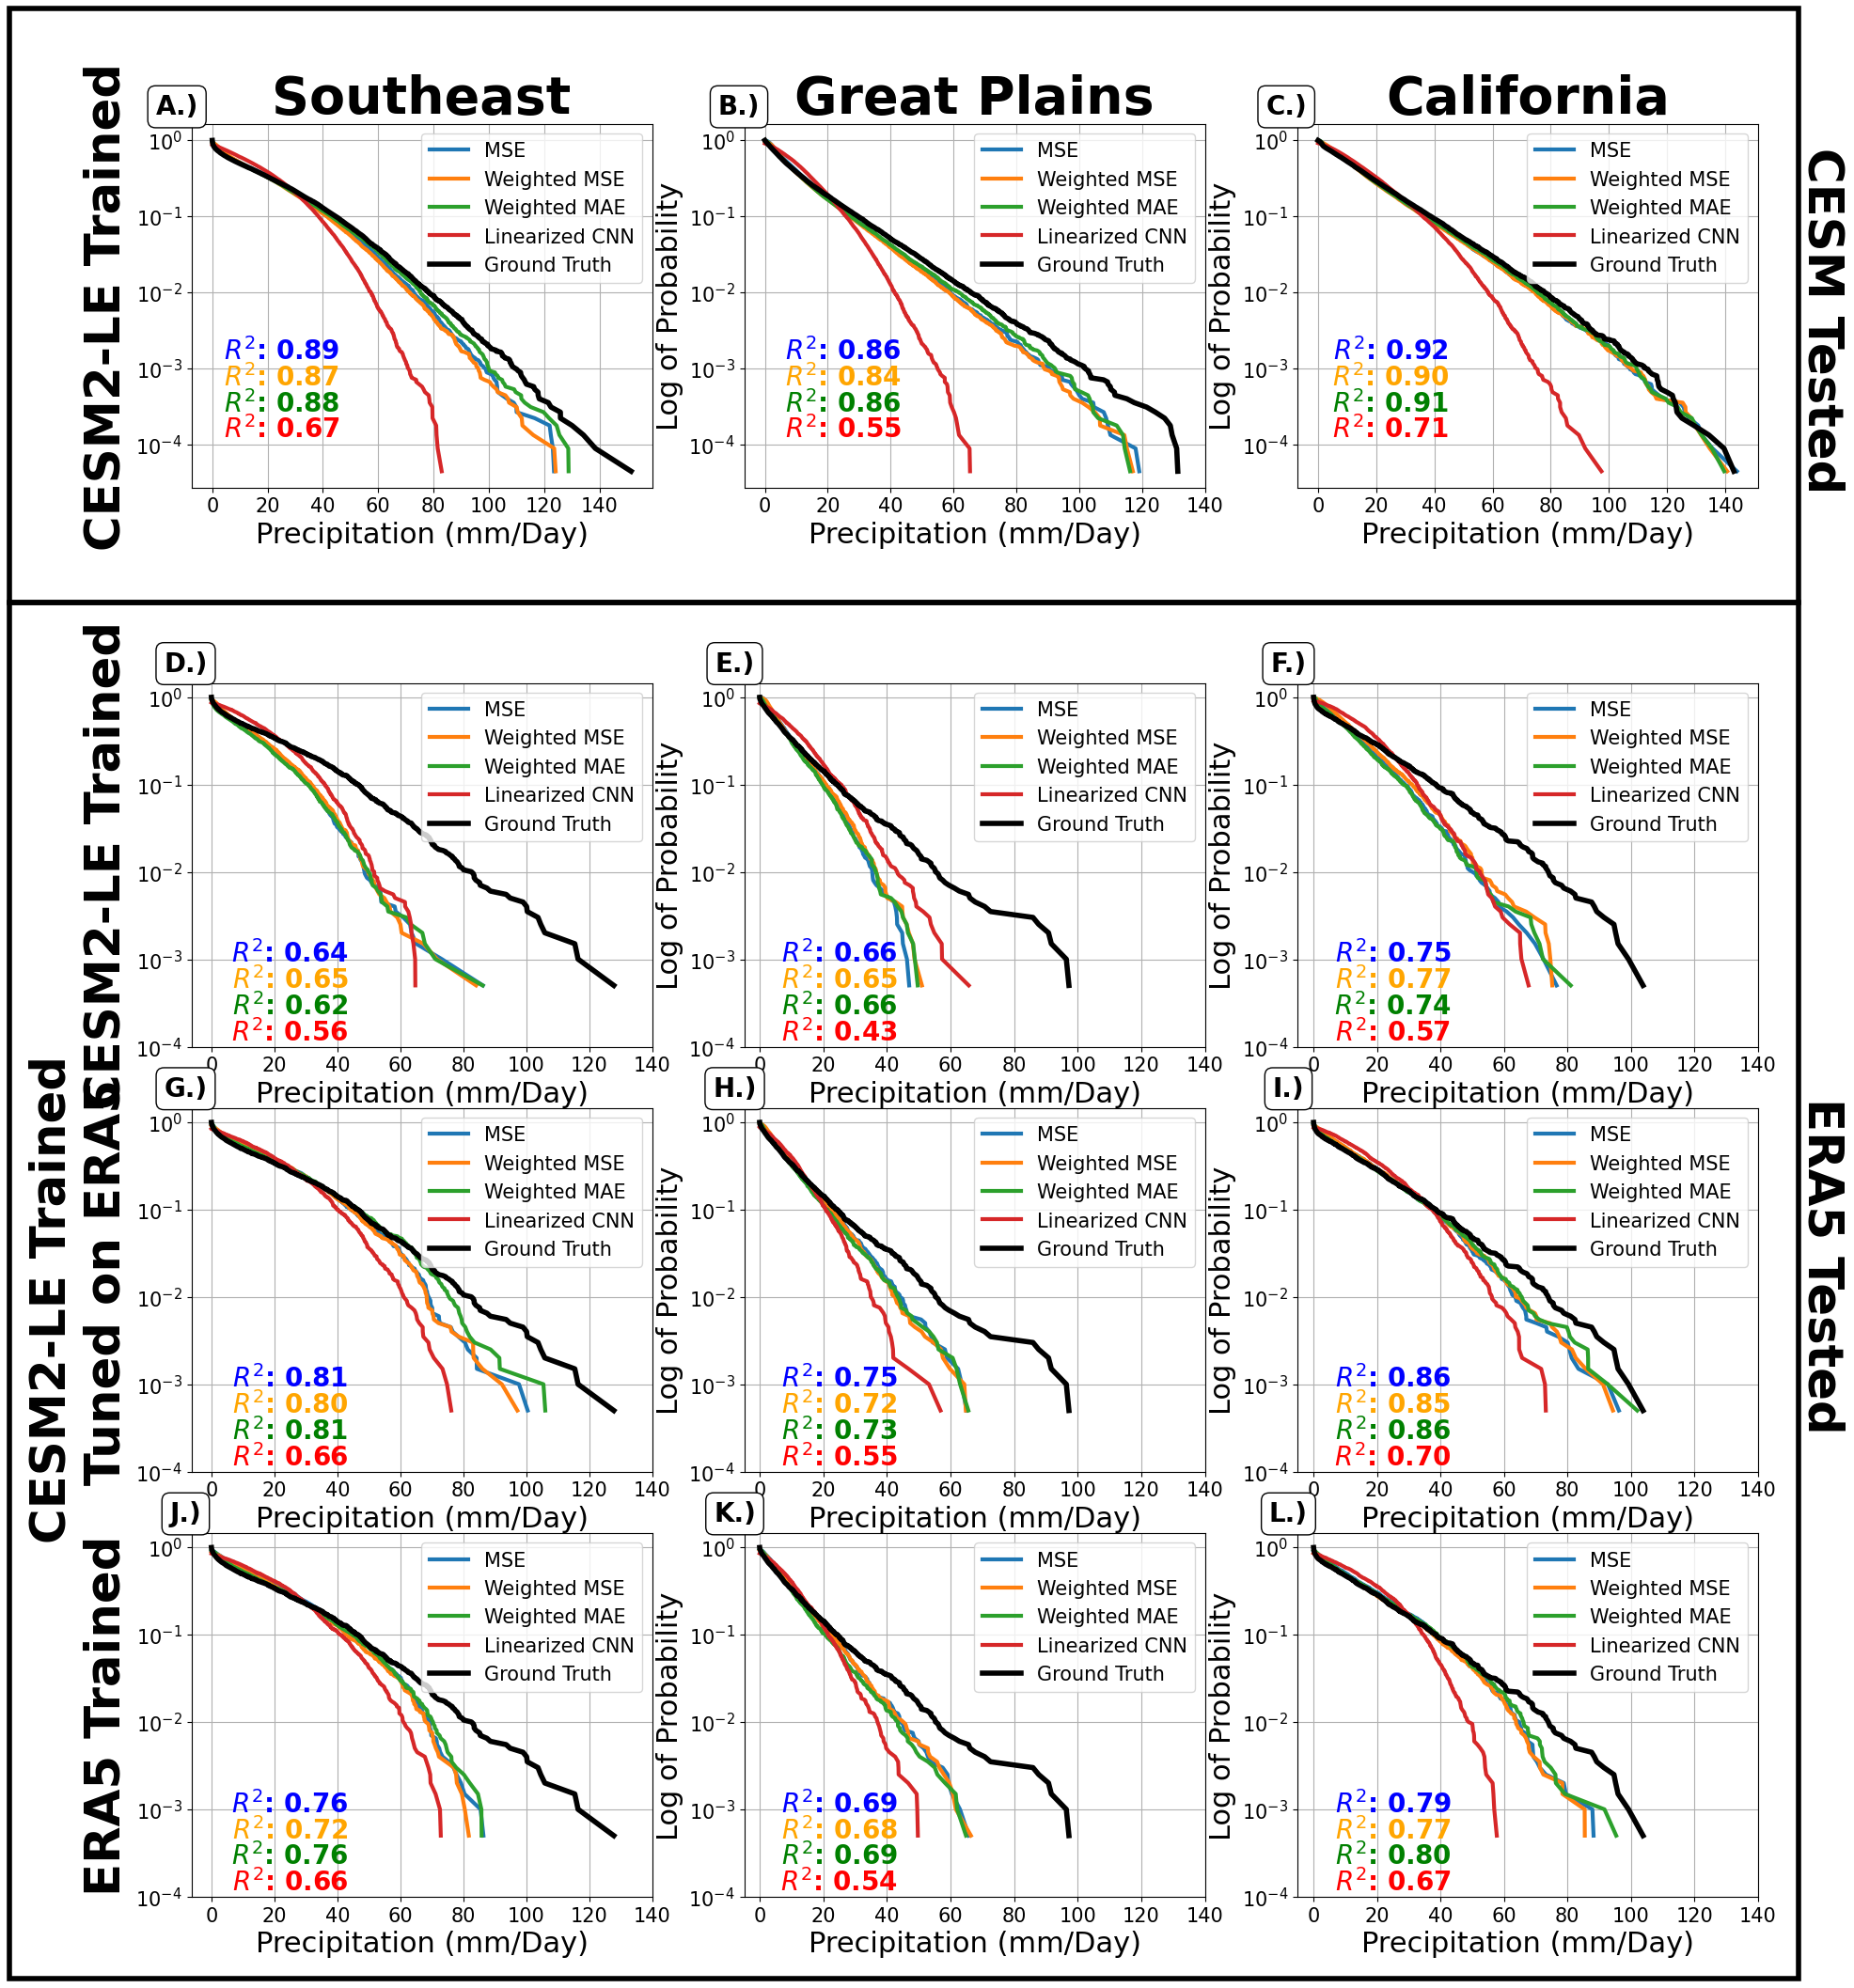

In [15]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

from matplotlib.transforms import Bbox

fig = plt.figure(figsize=(21.5, 24.5))
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.2, 1, 1, 1])  # Row 1 is spacer

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5', 
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']
regions = ['Southeast', 'Great Plains', 'California']
info = ['CESM2-LE Trained', 'CESM2-LE Trained', 'CESM2-LE Trained \n Tuned on ERA5', 'ERA5 Trained']
abc = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']

j = 0
axes = []  # Store subplot axes for later use (to calculate bounding boxes)

for num1, direct in enumerate(dirs):
    for num2, loc in enumerate(locs):
        row = j // 3
        col = j % 3
        if row == 1:
            ax = plt.subplot(gs[row + 1, col])
        elif row > 1:
            ax = plt.subplot(gs[row + 1, col])
        else:
            ax = plt.subplot(gs[row, col])
        axes.append(ax)
        j += 1

        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}']
            vals = df[columns_to_analyze].mean(axis=1)

            if datasets[num1] == 'cesm':
                vals = cesm_retrend(vals, locals()[f'{loc}_polyfit'])
                y_max = cesm_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'{loc}_polyfit'])
            else:
                vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
                y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

            ecdf = stats.ecdf(vals)
            ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=3)

            locals()[f'r_{model_type}'] = r2_score(y_max, vals)

        ecdf = stats.ecdf(y_max)
        ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=4, color='k')

        ax.legend(['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN', 'Ground Truth'], fontsize=15, loc='upper right')
        ax.set_xlabel('Precipitation (mm/Day)', fontsize=22)
        ax.set_ylabel('Log of Probability', fontsize=22)
        ax.set_xticks(np.arange(0, 150, 20))
        ax.set_xticklabels(np.arange(0, 150, 20), fontsize=15)
        ax.set_yticks(np.arange(0, -5, -1))
        ax.set_yticklabels(['$10^{0}$', '$10^{-1}$', '$10^{-2}$', '$10^{-3}$', '$10^{-4}$'], fontsize=15)
        ax.grid()

        if j <= 3:
            ax.set_title(f'{regions[num2]}', fontsize=40, fontweight='bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_mse)[:4]}', (25, -4), textcoords="offset points",
            xytext=(0,65), ha='center', color='blue', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mse)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,45), ha='center', color='orange', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mae)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,25), ha='center', color='green', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_line)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,5), ha='center', color='red', fontsize=20, fontweight='bold')
        
        ax.annotate(f'{abc[j-1]}.)', (25, 0), textcoords="offset points",  color='k', fontsize=20,
                    xytext=(-80, 20 + np.max(np.log10(1 - ecdf.cdf.probabilities))), ha='center',
                    bbox=dict(boxstyle='round', facecolor='w', alpha=1), fontweight='bold')

# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.09, cesm_bbox.y0 - 0.05),
    cesm_bbox.width + 0.11,
    cesm_bbox.height + 0.1,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.02, cesm_bbox.y1 - 0.01, 'CESM Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.09, era5_bbox.y0 - 0.22),
    era5_bbox.width + 0.11,
    era5_bbox.height + 0.255,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.02, era5_bbox.y1 - 0.18, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.savefig('cdfs_labeled.png', format='png', dpi=500, bbox_inches='tight')


## Precip Time Series

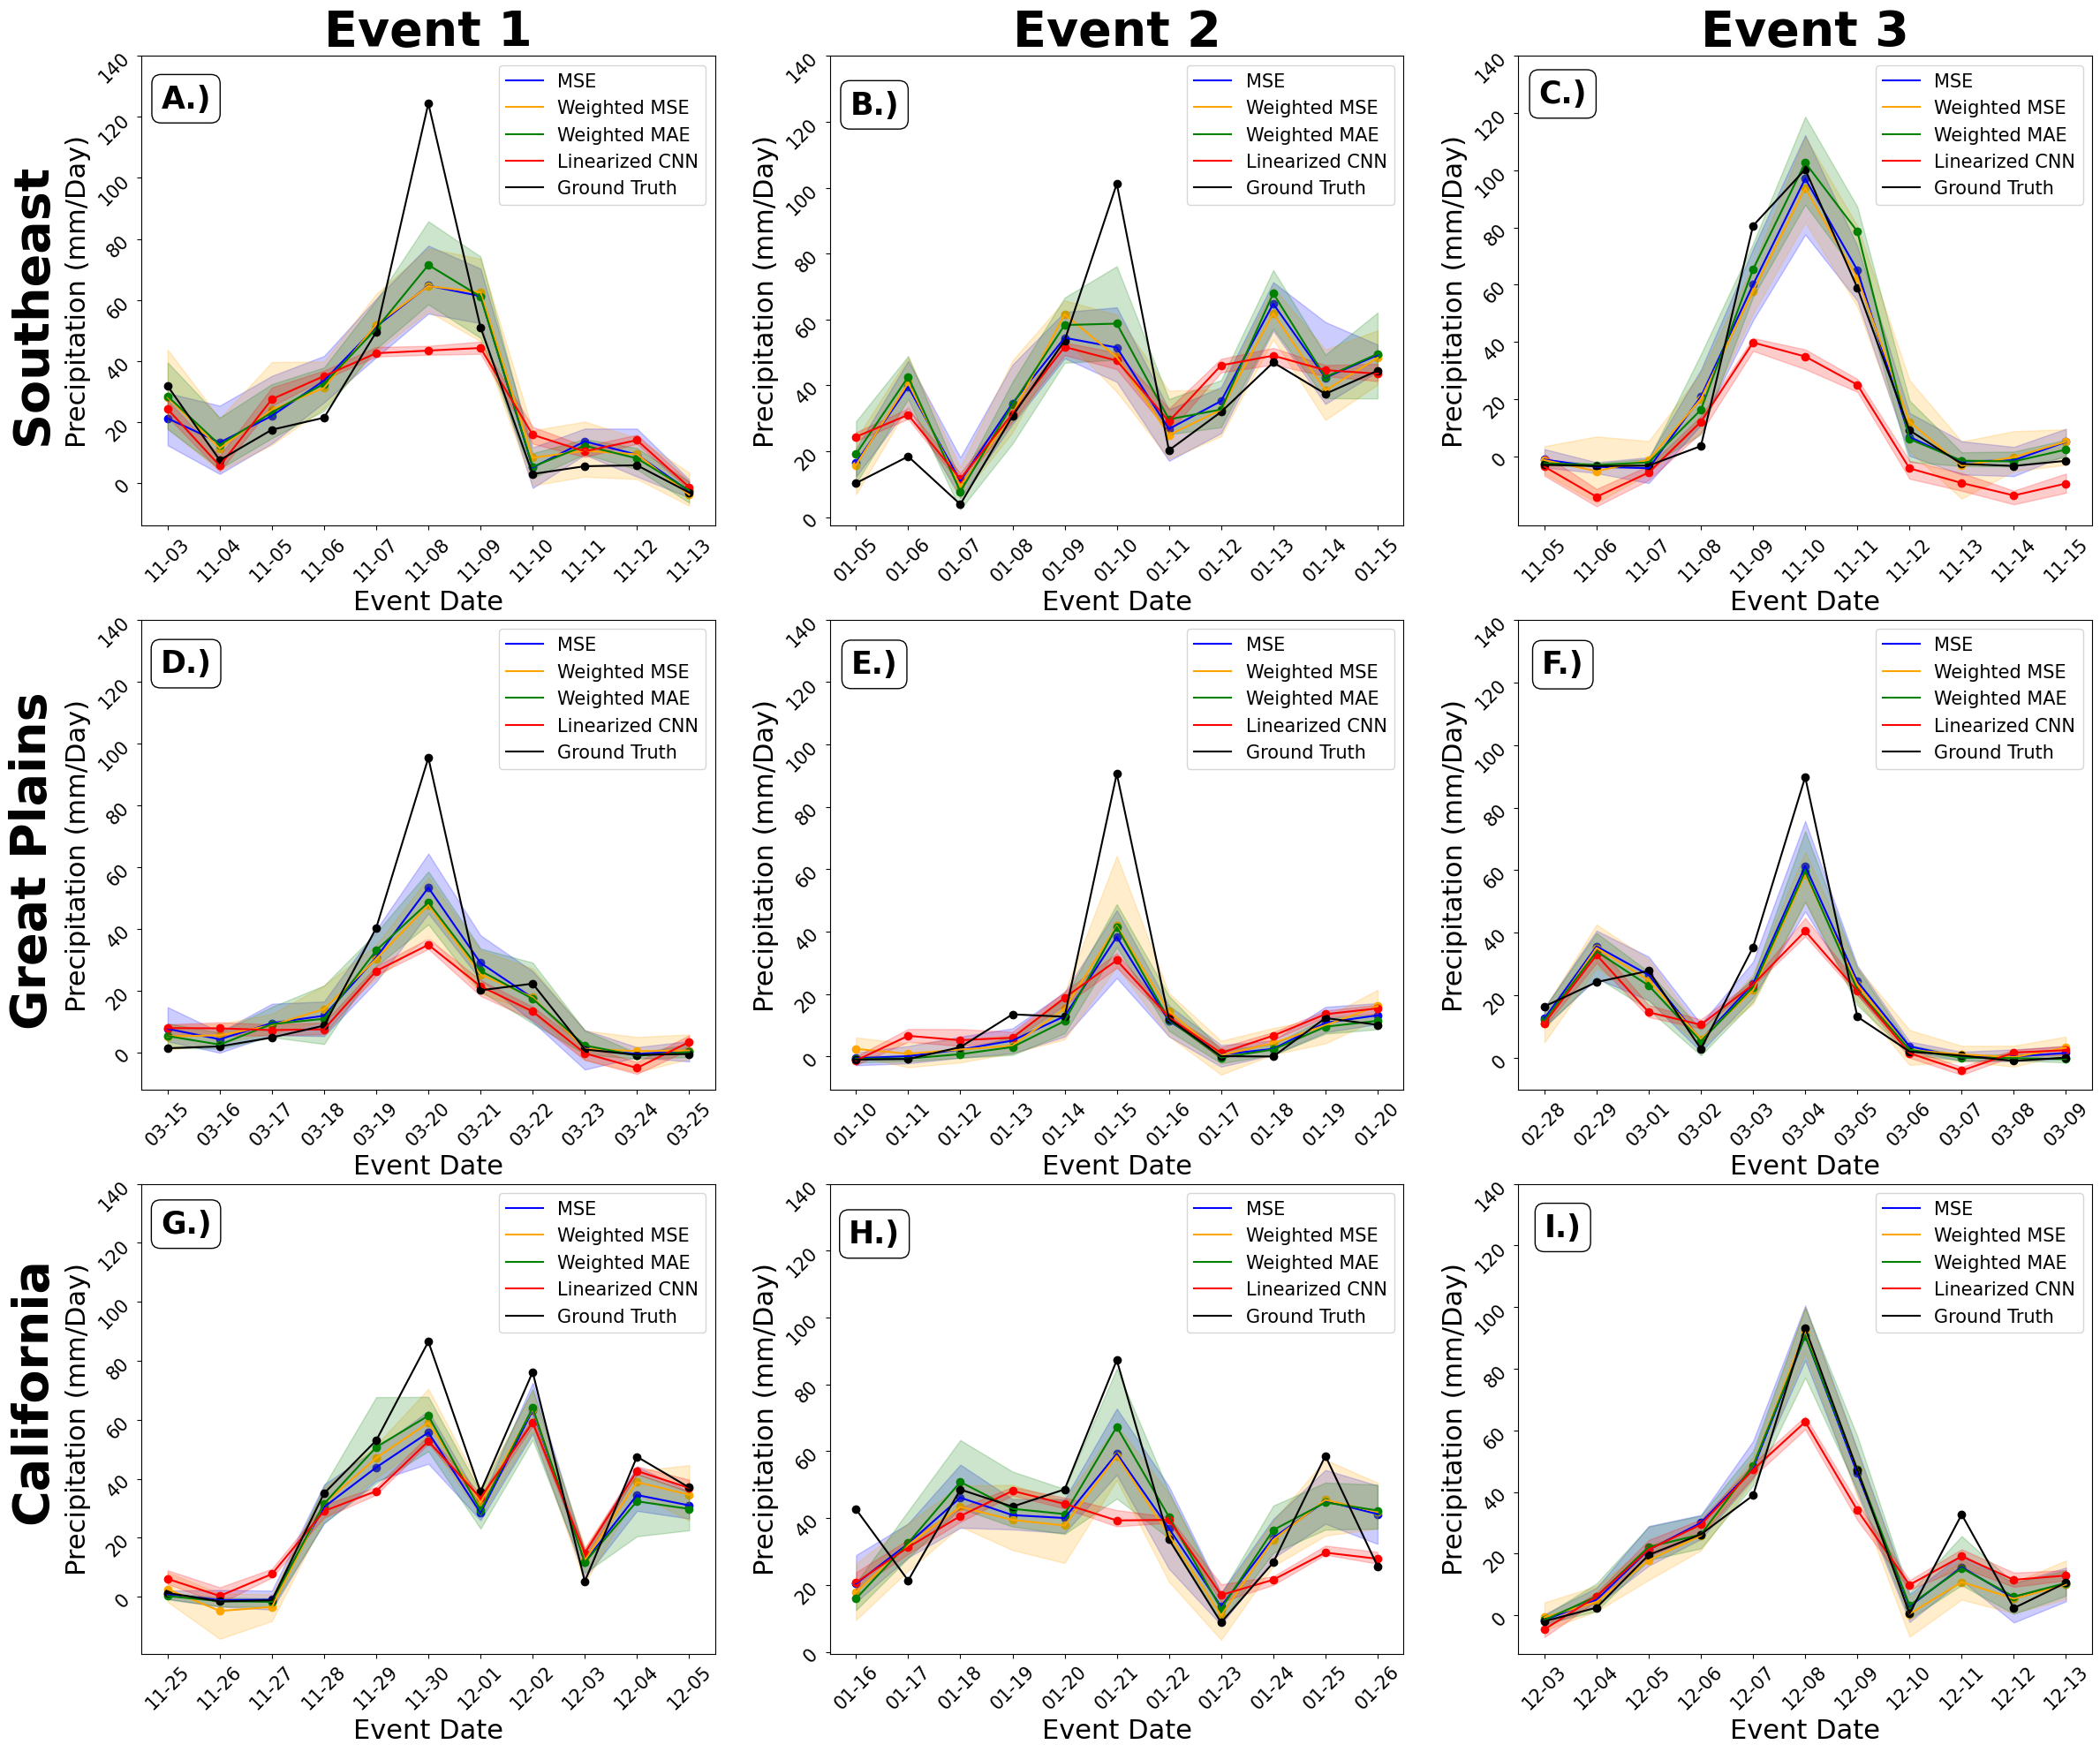

In [20]:
locs = ['se', 'gp', 'ca']
dirs = ['pre', 'pre', 'post', 'brute']
datasets = ['cesm', 'era5', 'era5', 'era5']
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']
colors = ['blue', 'orange', 'green', 'red']
model_type_names = ['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN']

events_ca = [9, 8, 5]
events_gp = [3, 4, 5]
events_se = [2, 6, 7]
event_names = ['Event 1', 'Event 2', 'Event 3']
abc = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']
j = 0

fig = plt.figure(figsize=(28.5, 23.5))

for num1, loc in enumerate(locs):
    for num2, event in enumerate(locals()[f'events_{loc}']):
        j += 1
        ax = plt.subplot(3,3,j)
        
        for num3, model_type in enumerate(model_types):
            df = locals()[f'df_post_era5_{loc}_{model_type}']
            df2 = locals()[f'df_{loc}_era5'][8000:]
            df = df.join(df2.reset_index(), how='inner')
            idx2 = df['Y_max_test'].nlargest(event).iloc[-1]
            index = df[df['Y_max_test'] == idx2].index[0]

            df_sub = df.iloc[max(index-5, 0): min(index+6, len(df))]
            mean = df_sub[columns_to_analyze].mean(axis=1).values
            mini = df_sub[columns_to_analyze].min(axis=1).values
            maxi = df_sub[columns_to_analyze].max(axis=1).values
            true = df_sub['Y_max_test'].values
            dates = np.array([x.split(' ')[0] for x in df_sub['Datetimes'].values])
            dates = [date[5:] for date in dates]

            plt.plot(dates, mean, color=colors[num3], label=model_type_names[num3])
            plt.scatter(dates, mean, color=colors[num3], label=None)
            plt.fill_between(dates, y1=mini, y2=maxi, color=colors[num3], alpha=0.2, label=None)

        plt.plot(dates, true, color='k', label='Ground Truth')
        plt.scatter(dates, true, color='k', label=None)

        plt.xlabel('Event Date', fontsize=22)
        plt.ylabel('Precipitation (mm/Day)', fontsize=22)
        plt.yticks(np.arange(0, 150, 20), np.arange(0, 150, 20), fontsize=15, rotation=45)
        plt.xticks(fontsize=15, rotation=45)
        plt.legend(fontsize=15)

        plt.annotate(f'{abc[j-1]}.)', (dates[0], 115), textcoords="offset points",  color='k', fontsize=25,
                    xytext=(15, 20), ha='center', bbox=dict(boxstyle='round', facecolor='w', alpha=1), fontweight='bold')

        if j <= 3:
            plt.title(f'{event_names[num2]}', fontsize=40).set_weight('bold')
        if num2 == 0:
            plt.annotate(f'{regions[num1]}', (dates[0], 40-[32, 37, 20][num1]), textcoords="offset points",  color='k', fontsize=40,
                    xytext=(-110, 20), ha='center', fontweight='bold', rotation=90)

plt.savefig('time_series_precip.png', format='png', dpi=500, bbox_inches='tight')


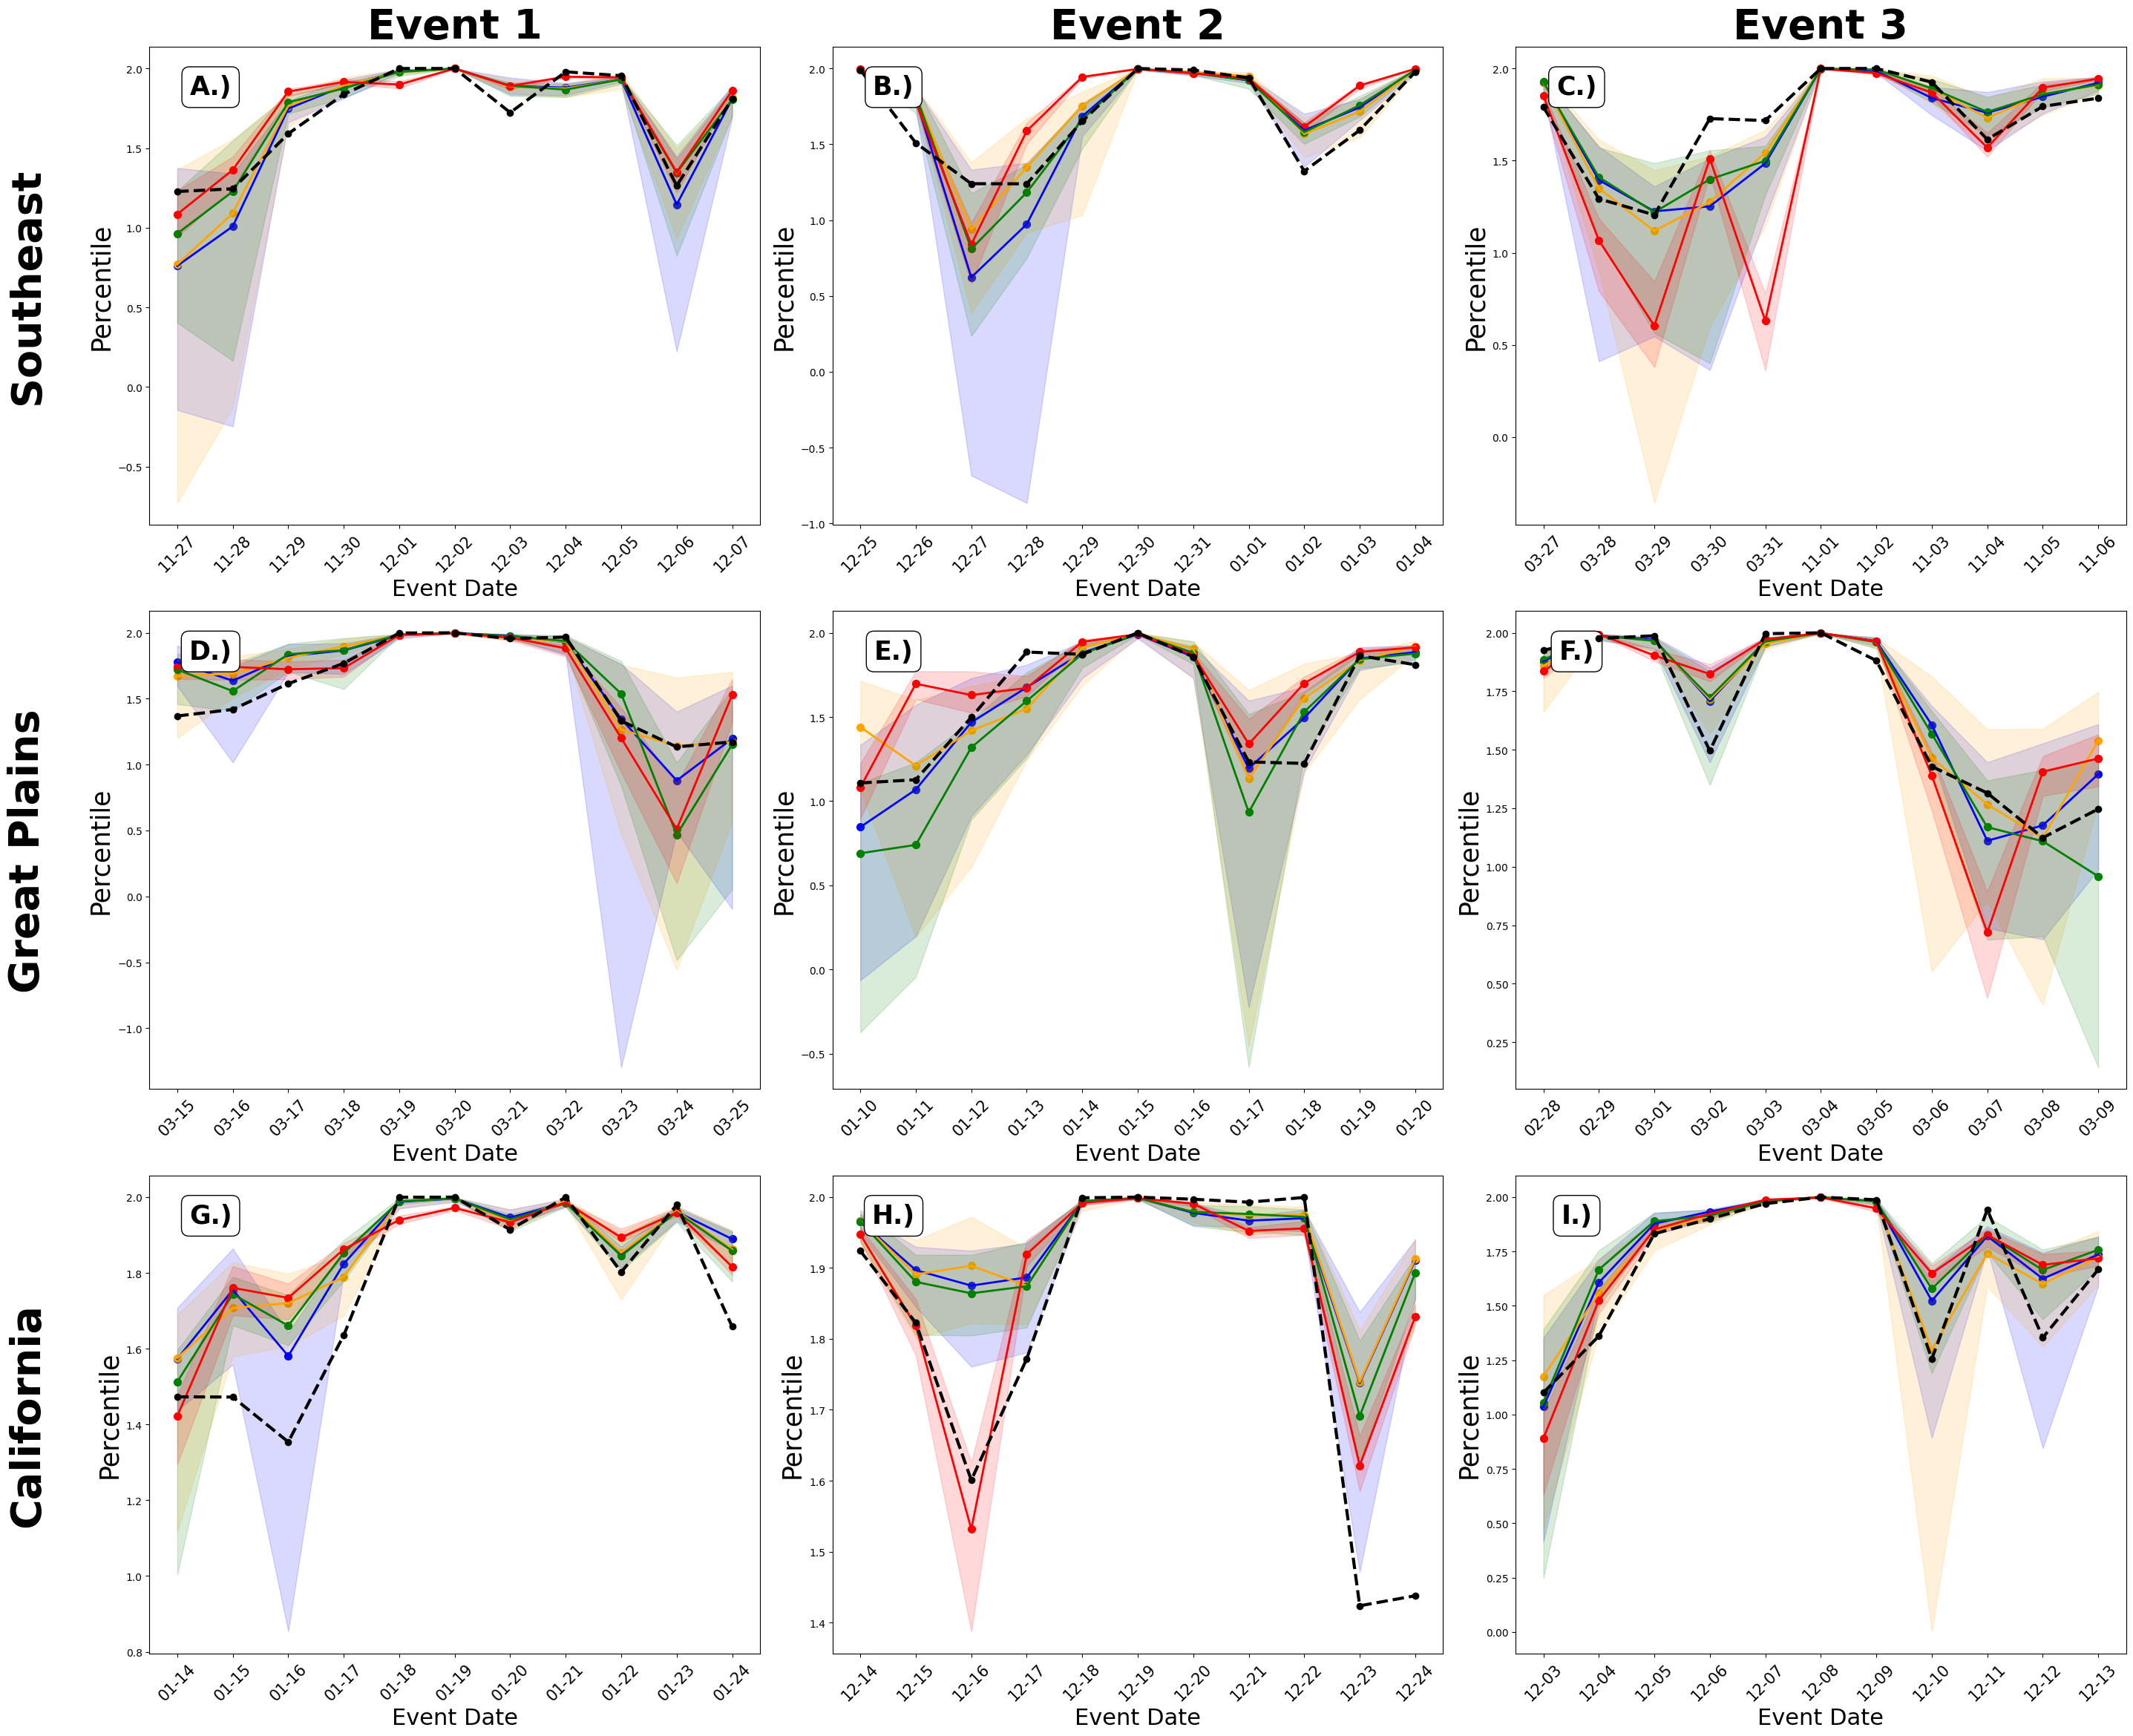

In [17]:
from scipy import stats

locs = ['se', 'gp', 'ca']
regions = ['Southeast', 'Great Plains', 'California'] # Added for the annotation logic
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']
colors = ['blue', 'orange', 'green', 'red']
model_type_names = ['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN']

event_names = ['Event 1', 'Event 2', 'Event 3']
abc = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']
j = 0

fig = plt.figure(figsize=(28.5, 23.5))

for num1, loc in enumerate(locs):
    # Dynamically grab the correct event list for this location
    events_list = locals()[f'events_{loc}']
    
    for num2, event in enumerate(events_list):
        j += 1
        ax = plt.subplot(3, 3, j)
        
        # We need to collect the true values to plot them once per subplot
        true_q = None
        plot_dates = None
        
        for num3, model_type in enumerate(model_types):
            # Load and join data
            df = locals()[f'df_post_era5_{loc}_{model_type}']
            df2 = locals()[f'df_{loc}_era5'][8000:]
            df = df.join(df2.reset_index(), how='inner')
            
            # Find the specific event index based on Y_max_test
            idx2 = df['Y_max_test'].nlargest(event).iloc[-1]
            index = df[df['Y_max_test'] == idx2].index[0]

            # Slice the 11-day window
            df_sub = df.iloc[max(index-5, 0): min(index+6, len(df))]
            
            # --- QUANTILE TRANSFORMATION LOGIC ---
            # 1. Define the full historical distribution for this specific model/location
            # This is the "population" we use to determine percentiles
            history = df[columns_to_analyze].values.flatten()
            
            # 2. Extract raw values for the current window
            raw_mean = df_sub[columns_to_analyze].mean(axis=1).values
            raw_mini = df_sub[columns_to_analyze].min(axis=1).values
            raw_maxi = df_sub[columns_to_analyze].max(axis=1).values
            raw_true = df_sub['Y_max_test'].values
            
            # 3. Convert raw mm/Day to Percentile (0-100)
            # We use the full 'history' as the reference distribution
            mean_q = [stats.percentileofscore(history, v) for v in raw_mean]
            mini_q = [stats.percentileofscore(history, v) for v in raw_mini]
            maxi_q = [stats.percentileofscore(history, v) for v in raw_maxi]
            
            # Transformation for Ground Truth (using model history for consistency)
            current_true_q = [stats.percentileofscore(history, v) for v in raw_true]

            # Prepare dates for plotting
            dates = np.array([x.split(' ')[0] for x in df_sub['Datetimes'].values])
            dates = [date[5:] for date in dates]
            plot_dates = dates
            true_q = current_true_q # Save for the black line plot later

            # Plot Model Quantiles
            plt.plot(dates, np.log10(mean_q), color=colors[num3], label=model_type_names[num3], linewidth=2)
            plt.scatter(dates, np.log10(mean_q), color=colors[num3], s=50)
            plt.fill_between(dates, y1=np.log10(mini_q), y2=np.log10(maxi_q), color=colors[num3], alpha=0.15)

        # Plot Ground Truth (Percentile version)
        if true_q is not None:
            plt.plot(plot_dates, np.log10(true_q), color='k', label='Ground Truth', linewidth=3, linestyle='--')
            plt.scatter(plot_dates, np.log10(true_q), color='k', zorder=5)

        # Aesthetics
        plt.xlabel('Event Date', fontsize=22)
        plt.ylabel('Percentile', fontsize=25)
        
        # Set Y-Axis to 0-100%
        #plt.ylim(0, 1)
        #plt.yticks(np.arange(0, 101, 20), [f'{x}%' for x in np.arange(0, 101, 20)], fontsize=15)
        plt.xticks(fontsize=15, rotation=45)
        #plt.legend(fontsize=14, loc='lower right')

        # Annotations (A, B, C...)
        plt.annotate(f'{abc[j-1]}.)', (0.1, 0.9), xycoords='axes fraction', color='k', fontsize=25,
                    ha='center', bbox=dict(boxstyle='round', facecolor='w', alpha=1), fontweight='bold')

        if j <= 3:
            plt.title(f'{event_names[num2]}', fontsize=40, fontweight='bold')
        
        if num2 == 0:
            # Region label on the far left
            ax.text(-0.2, 0.5, f'{regions[num1]}', transform=ax.transAxes, 
                    fontsize=40, fontweight='bold', rotation=90, va='center', ha='center')

plt.tight_layout()
plt.savefig('time_series_quantile_precip.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
df

,Y_max_test,y_pred1,y_pred2,y_pred3,y_pred4,y_pred5,y_pred6,y_pred7,y_pred8,y_pred9,y_pred10
0,71.611290,69.499046,70.713783,68.641273,69.181297,71.644920,68.821304,67.130821,68.645576,71.637215,71.168068
1,27.713291,31.690407,31.259350,32.324657,31.410589,34.503658,30.817066,31.760431,32.378178,32.084332,33.898392
2,12.510766,11.353765,12.728011,11.655256,12.575293,10.054732,10.025644,12.932379,13.036349,12.799401,13.736957
3,32.448048,28.282885,26.087805,25.963329,27.443678,26.613380,26.564608,26.199112,27.748205,27.356777,27.938025
4,35.988832,41.000755,42.837307,41.826027,39.805016,41.569679,42.705173,42.062389,42.767399,42.433372,41.741386
...,...,...,...,...,...,...,...,...,...,...,...
1977,11.521154,13.259630,13.951095,15.807329,13.485521,15.486604,15.954835,14.392585,14.197730,17.575426,14.294115
1978,7.354265,16.629242,16.226759,15.372847,15.675214,17.119923,15.391738,14.406718,15.936956,16.211433,14.536217
1979,3.337075,5.343861,3.121619,4.419887,2.994917,5.155528,3.832124,4.573603,5.220215,5.655730,2.481383
1980,6.232238,13.050381,11.662814,8.574623,10.105901,11.296728,12.115745,14.657234,12.870410,9.882992,11.072470


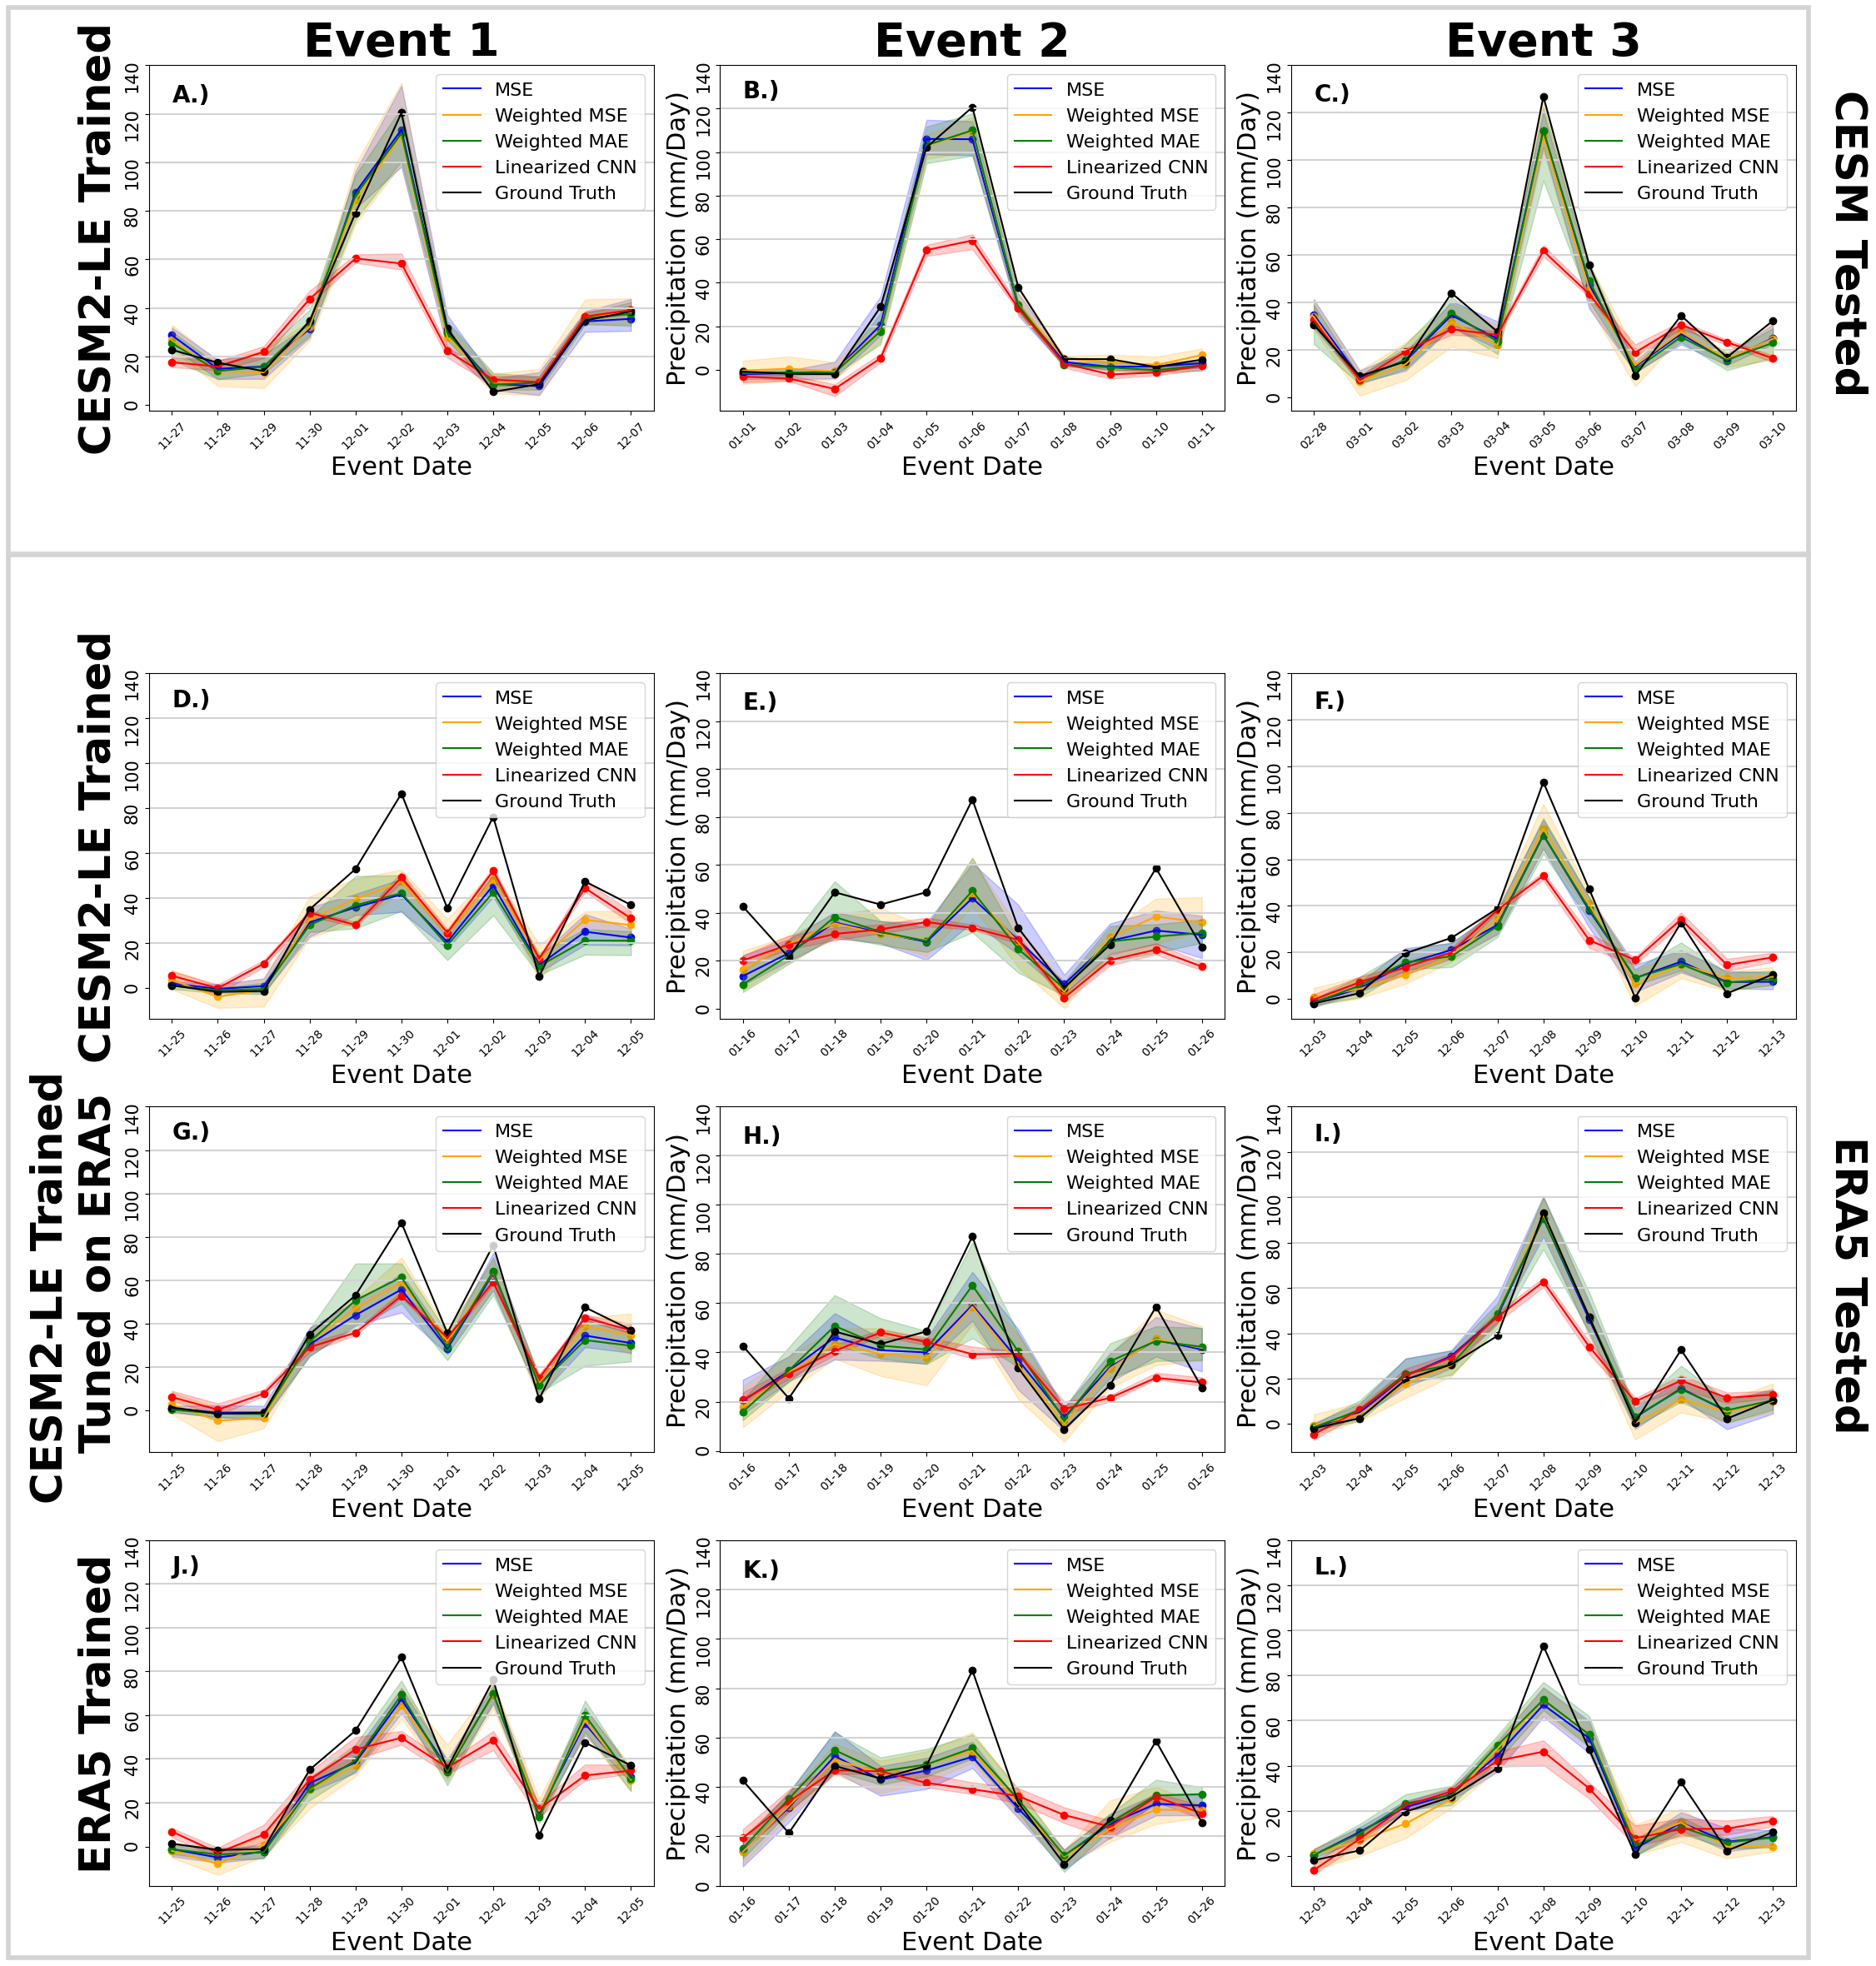

In [19]:
import matplotlib.gridspec as gridspec

j = 0
fig = plt.figure(figsize=(21.5, 24.5))

# Insert a spacer row after the first row
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.25, 1, 1, 1])

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5',
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']

colors = ['blue', 'orange', 'green', 'red']
event_names = ['Event 1', 'Event 2', 'Event 3']
model_type_names = ['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN']
abc = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']
events = [9, 8, 5]
loc = 'ca'

for num1, direct in enumerate(dirs):
    for num2, event in enumerate(events):
        # Calculate grid position with spacer row after row 1
        row = j // 3
        col = j % 3
        row_in_grid = row if row == 0 else row + 1
        ax = plt.subplot(gs[row_in_grid, col])
        j += 1

        for num3, model_type in enumerate(model_types):
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}']
            idx2 = df['Y_max_test'].nlargest(event).iloc[-1]
            index = df[df['Y_max_test'] == idx2].index[0]

            if datasets[num1] == 'cesm':
                df1 = df
                df2 = locals()[f'df_{loc}_{datasets[num1]}']
                df = df.join(df2.reset_index(), how='inner')
            else:
                df2 = locals()[f'df_{loc}_{datasets[num1]}'][8000:]
                df = df.join(df2.reset_index(), how='inner')

            df_sub = df.iloc[max(index-5, 0): min(index+6, len(df))]
            mean = df_sub[columns_to_analyze].mean(axis=1).values
            mini = df_sub[columns_to_analyze].min(axis=1).values
            maxi = df_sub[columns_to_analyze].max(axis=1).values
            true = df_sub['Y_max_test'].values
            dates = np.array([x.split(' ')[0] for x in df_sub['Datetimes'].values])
            dates = [date[5:] for date in dates]

            plt.plot(dates, mean, color=colors[num3], label=model_type_names[num3])
            plt.scatter(dates, mean, color=colors[num3], label=None)
            plt.fill_between(dates, y1=mini, y2=maxi, color=colors[num3], alpha=0.2, label=None)

        plt.plot(dates, true, color='k', label='Ground Truth')
        plt.scatter(dates, true, color='k', label=None)

        plt.xlabel('Event Date', fontsize=22)
        plt.ylabel('Precipitation (mm/Day)', fontsize=22)
        plt.yticks(np.arange(0, 150, 20), np.arange(0, 150, 20), fontsize=15, rotation=90)
        plt.xticks(fontsize=10, rotation=45)
        plt.legend(fontsize=16, loc='upper right')
        plt.axhline(20, color='lightgrey',  zorder=1)
        plt.axhline(40, color='lightgrey',  zorder=1)
        plt.axhline(60, color='lightgrey',  zorder=1)
        plt.axhline(80, color='lightgrey',  zorder=1)
        plt.axhline(100, color='lightgrey',  zorder=1)
        plt.axhline(120, color='lightgrey',  zorder=1)

        plt.text(0, 125, f'{abc[j-1]}.)',  color='k', fontsize=20, fontweight='bold')

        if j <= 3:
            plt.title(f'{event_names[num2]}', fontsize=40).set_weight('bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37).set_weight('bold')
            
# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.13, cesm_bbox.y0 - 0.03),
    cesm_bbox.width + 0.23,
    cesm_bbox.height + 0.11,
    linewidth=4,
    edgecolor='lightgrey',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.11, cesm_bbox.y1 + 0.04, 'CESM Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.13, era5_bbox.y0 - 0.29),
    era5_bbox.width + 0.23,
    era5_bbox.height + 0.345,
    linewidth=4,
    edgecolor='lightgrey',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.11, era5_bbox.y1 - 0.23, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{loc}_precip_ts.png', format='png', dpi=500, bbox_inches='tight')


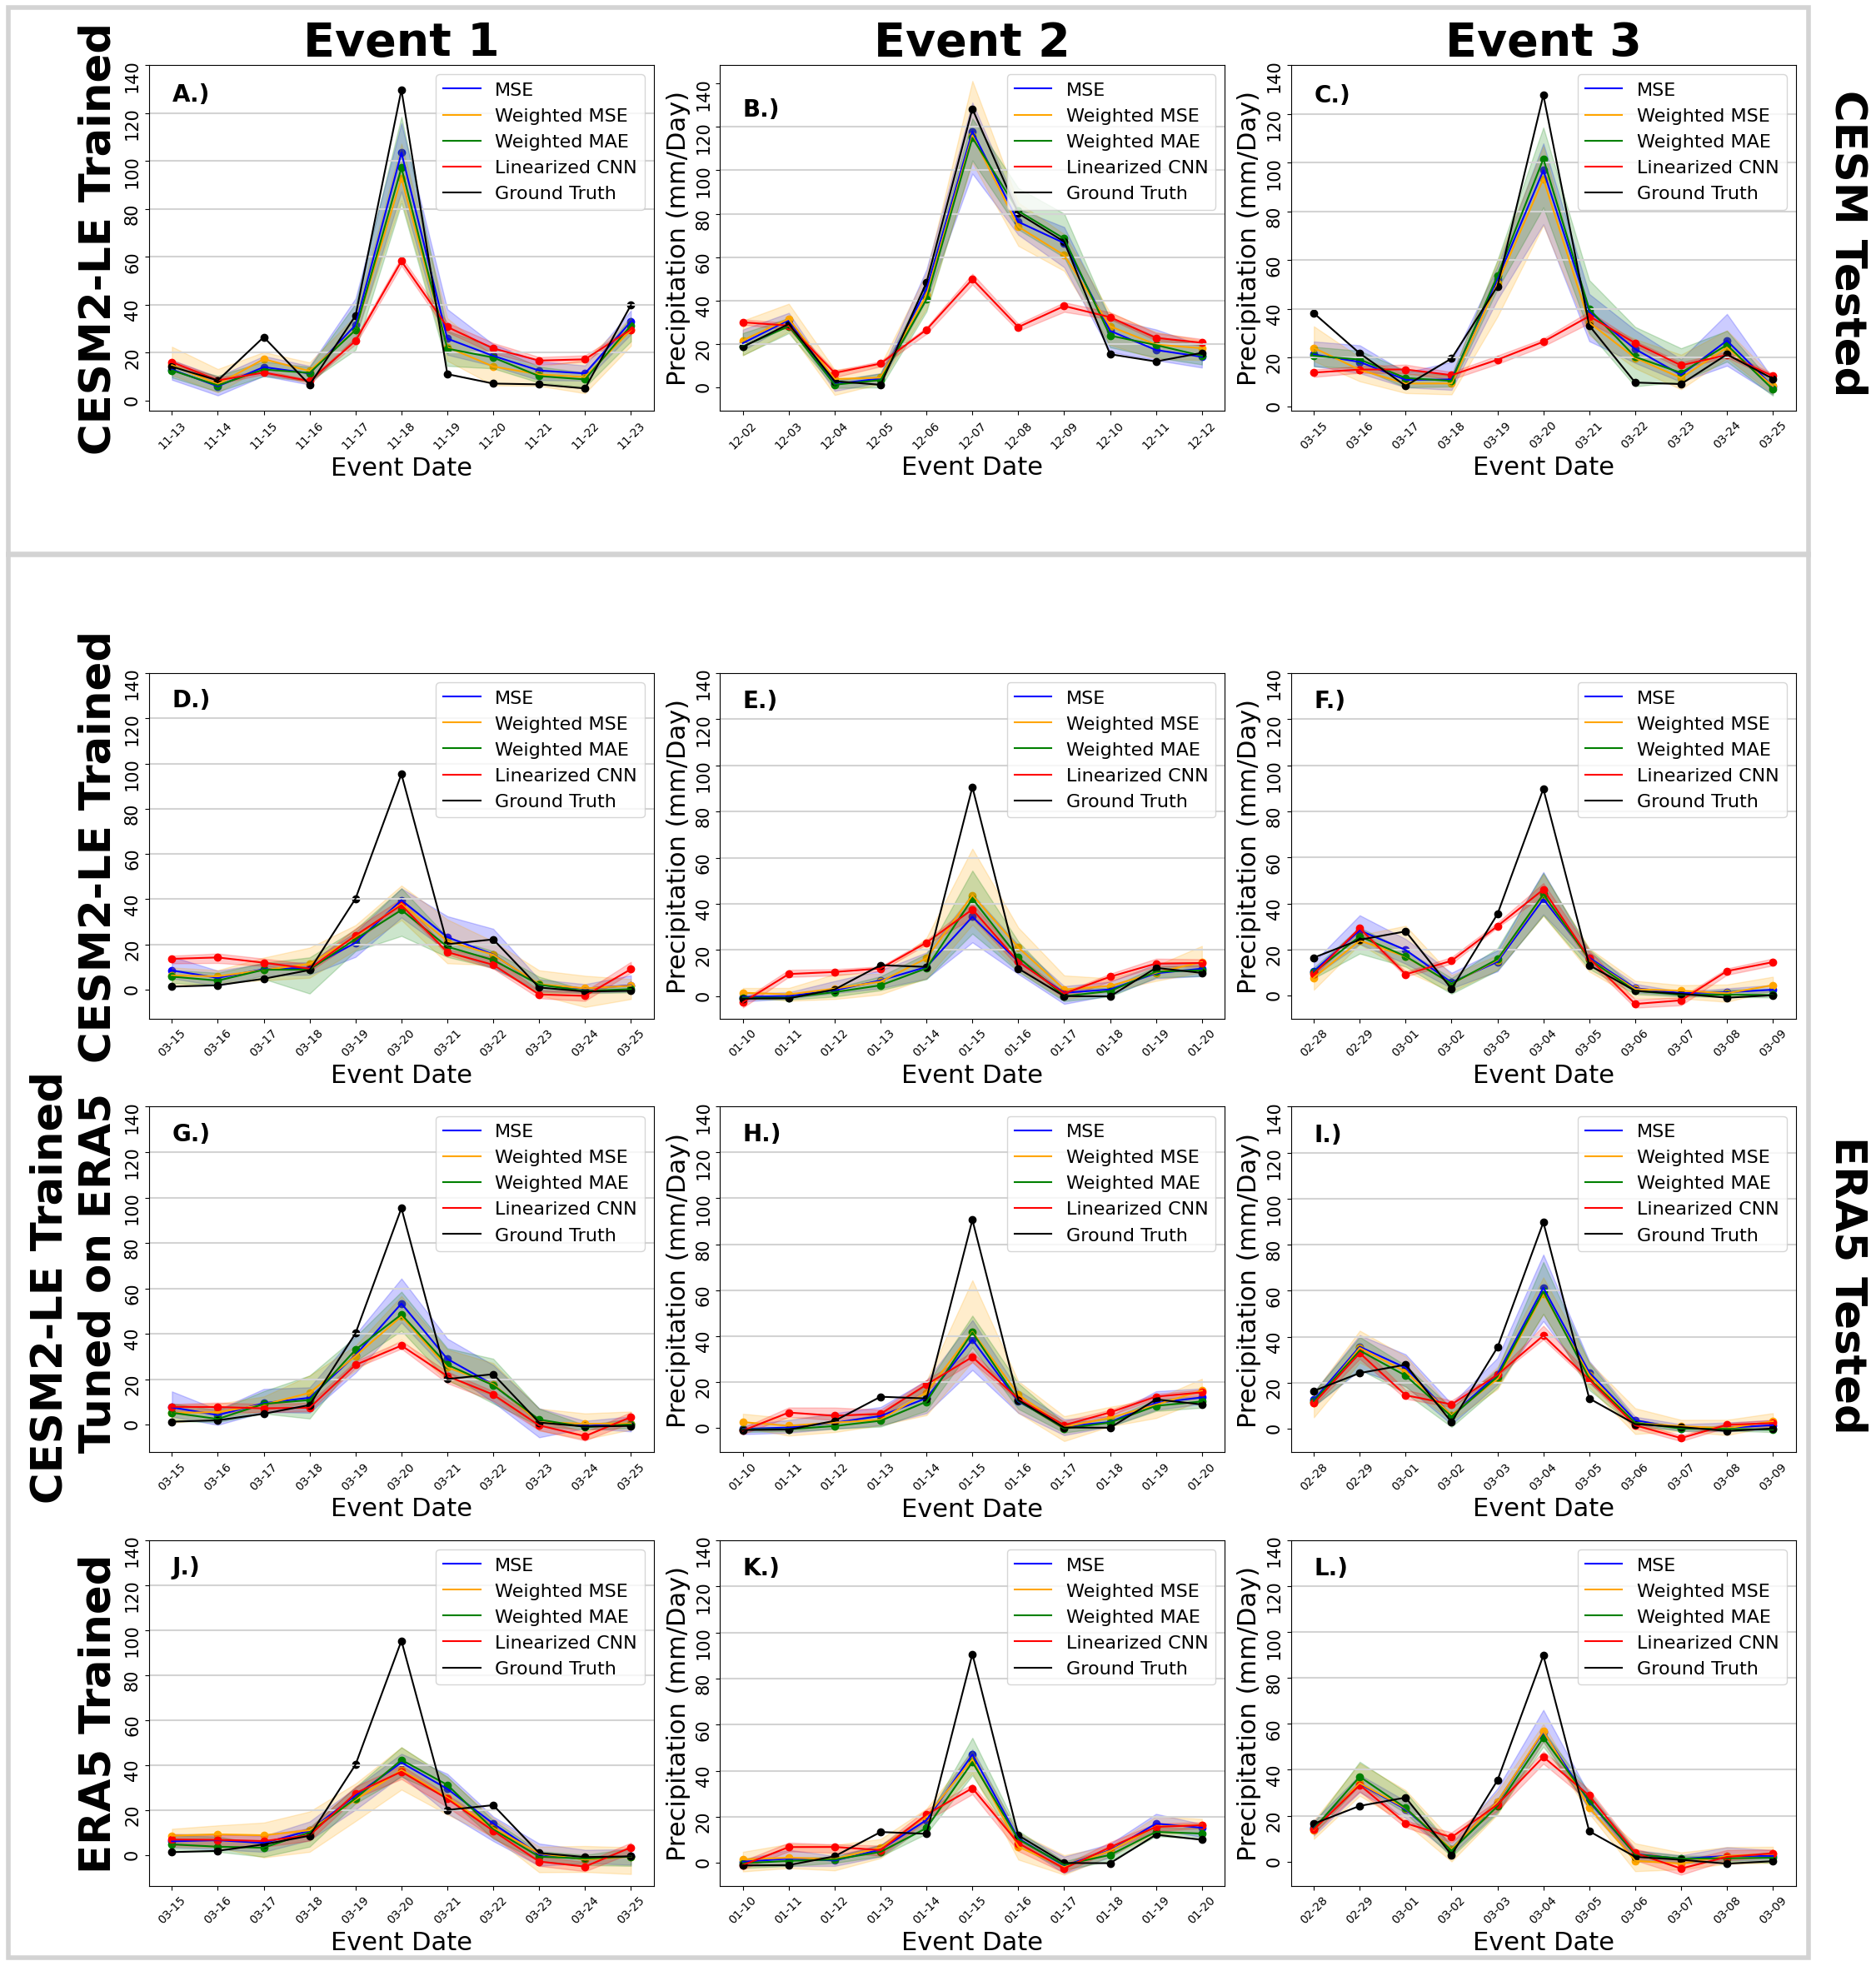

In [20]:
import matplotlib.gridspec as gridspec

j = 0
fig = plt.figure(figsize=(21.5, 24.5))

# Insert a spacer row after the first row
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.25, 1, 1, 1])

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5',
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']

colors = ['blue', 'orange', 'green', 'red']
event_names = ['Event 1', 'Event 2', 'Event 3']
model_type_names = ['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN']
events = [3, 4, 5]
loc = 'gp'

for num1, direct in enumerate(dirs):
    for num2, event in enumerate(events):
        # Calculate grid position with spacer row after row 1
        row = j // 3
        col = j % 3
        row_in_grid = row if row == 0 else row + 1
        ax = plt.subplot(gs[row_in_grid, col])
        j += 1

        for num3, model_type in enumerate(model_types):
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}']
            idx2 = df['Y_max_test'].nlargest(event).iloc[-1]
            index = df[df['Y_max_test'] == idx2].index[0]

            if datasets[num1] == 'cesm':
                df1 = df
                df2 = locals()[f'df_{loc}_{datasets[num1]}']
                df = df.join(df2.reset_index(), how='inner')
            else:
                df2 = locals()[f'df_{loc}_{datasets[num1]}'][8000:]
                df = df.join(df2.reset_index(), how='inner')

            df_sub = df.iloc[max(index-5, 0): min(index+6, len(df))]
            mean = df_sub[columns_to_analyze].mean(axis=1).values
            mini = df_sub[columns_to_analyze].min(axis=1).values
            maxi = df_sub[columns_to_analyze].max(axis=1).values
            true = df_sub['Y_max_test'].values
            dates = np.array([x.split(' ')[0] for x in df_sub['Datetimes'].values])
            dates = [date[5:] for date in dates]

            plt.plot(dates, mean, color=colors[num3], label=model_type_names[num3])
            plt.scatter(dates, mean, color=colors[num3], label=None)
            plt.fill_between(dates, y1=mini, y2=maxi, color=colors[num3], alpha=0.2, label=None)

        plt.plot(dates, true, color='k', label='Ground Truth')
        plt.scatter(dates, true, color='k', label=None)

        plt.xlabel('Event Date', fontsize=22)
        plt.ylabel('Precipitation (mm/Day)', fontsize=22)
        plt.yticks(np.arange(0, 150, 20), np.arange(0, 150, 20), fontsize=15, rotation=90)
        plt.xticks(fontsize=10, rotation=45)
        plt.legend(fontsize=16, loc='upper right')
        plt.axhline(20, color='lightgrey',  zorder=1)
        plt.axhline(40, color='lightgrey',  zorder=1)
        plt.axhline(60, color='lightgrey',  zorder=1)
        plt.axhline(80, color='lightgrey',  zorder=1)
        plt.axhline(100, color='lightgrey',  zorder=1)
        plt.axhline(120, color='lightgrey',  zorder=1)

        plt.text(0, 125, f'{abc[j-1]}.)',  color='k', fontsize=20, fontweight='bold')

        if j <= 3:
            plt.title(f'{event_names[num2]}', fontsize=40).set_weight('bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37).set_weight('bold')
            
# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.13, cesm_bbox.y0 - 0.03),
    cesm_bbox.width + 0.23,
    cesm_bbox.height + 0.11,
    linewidth=4,
    edgecolor='lightgrey',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.11, cesm_bbox.y1 + 0.04, 'CESM Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.13, era5_bbox.y0 - 0.29),
    era5_bbox.width + 0.23,
    era5_bbox.height + 0.345,
    linewidth=4,
    edgecolor='lightgrey',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.11, era5_bbox.y1 - 0.23, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{loc}_precip_ts.png', format='png', dpi=500, bbox_inches='tight')


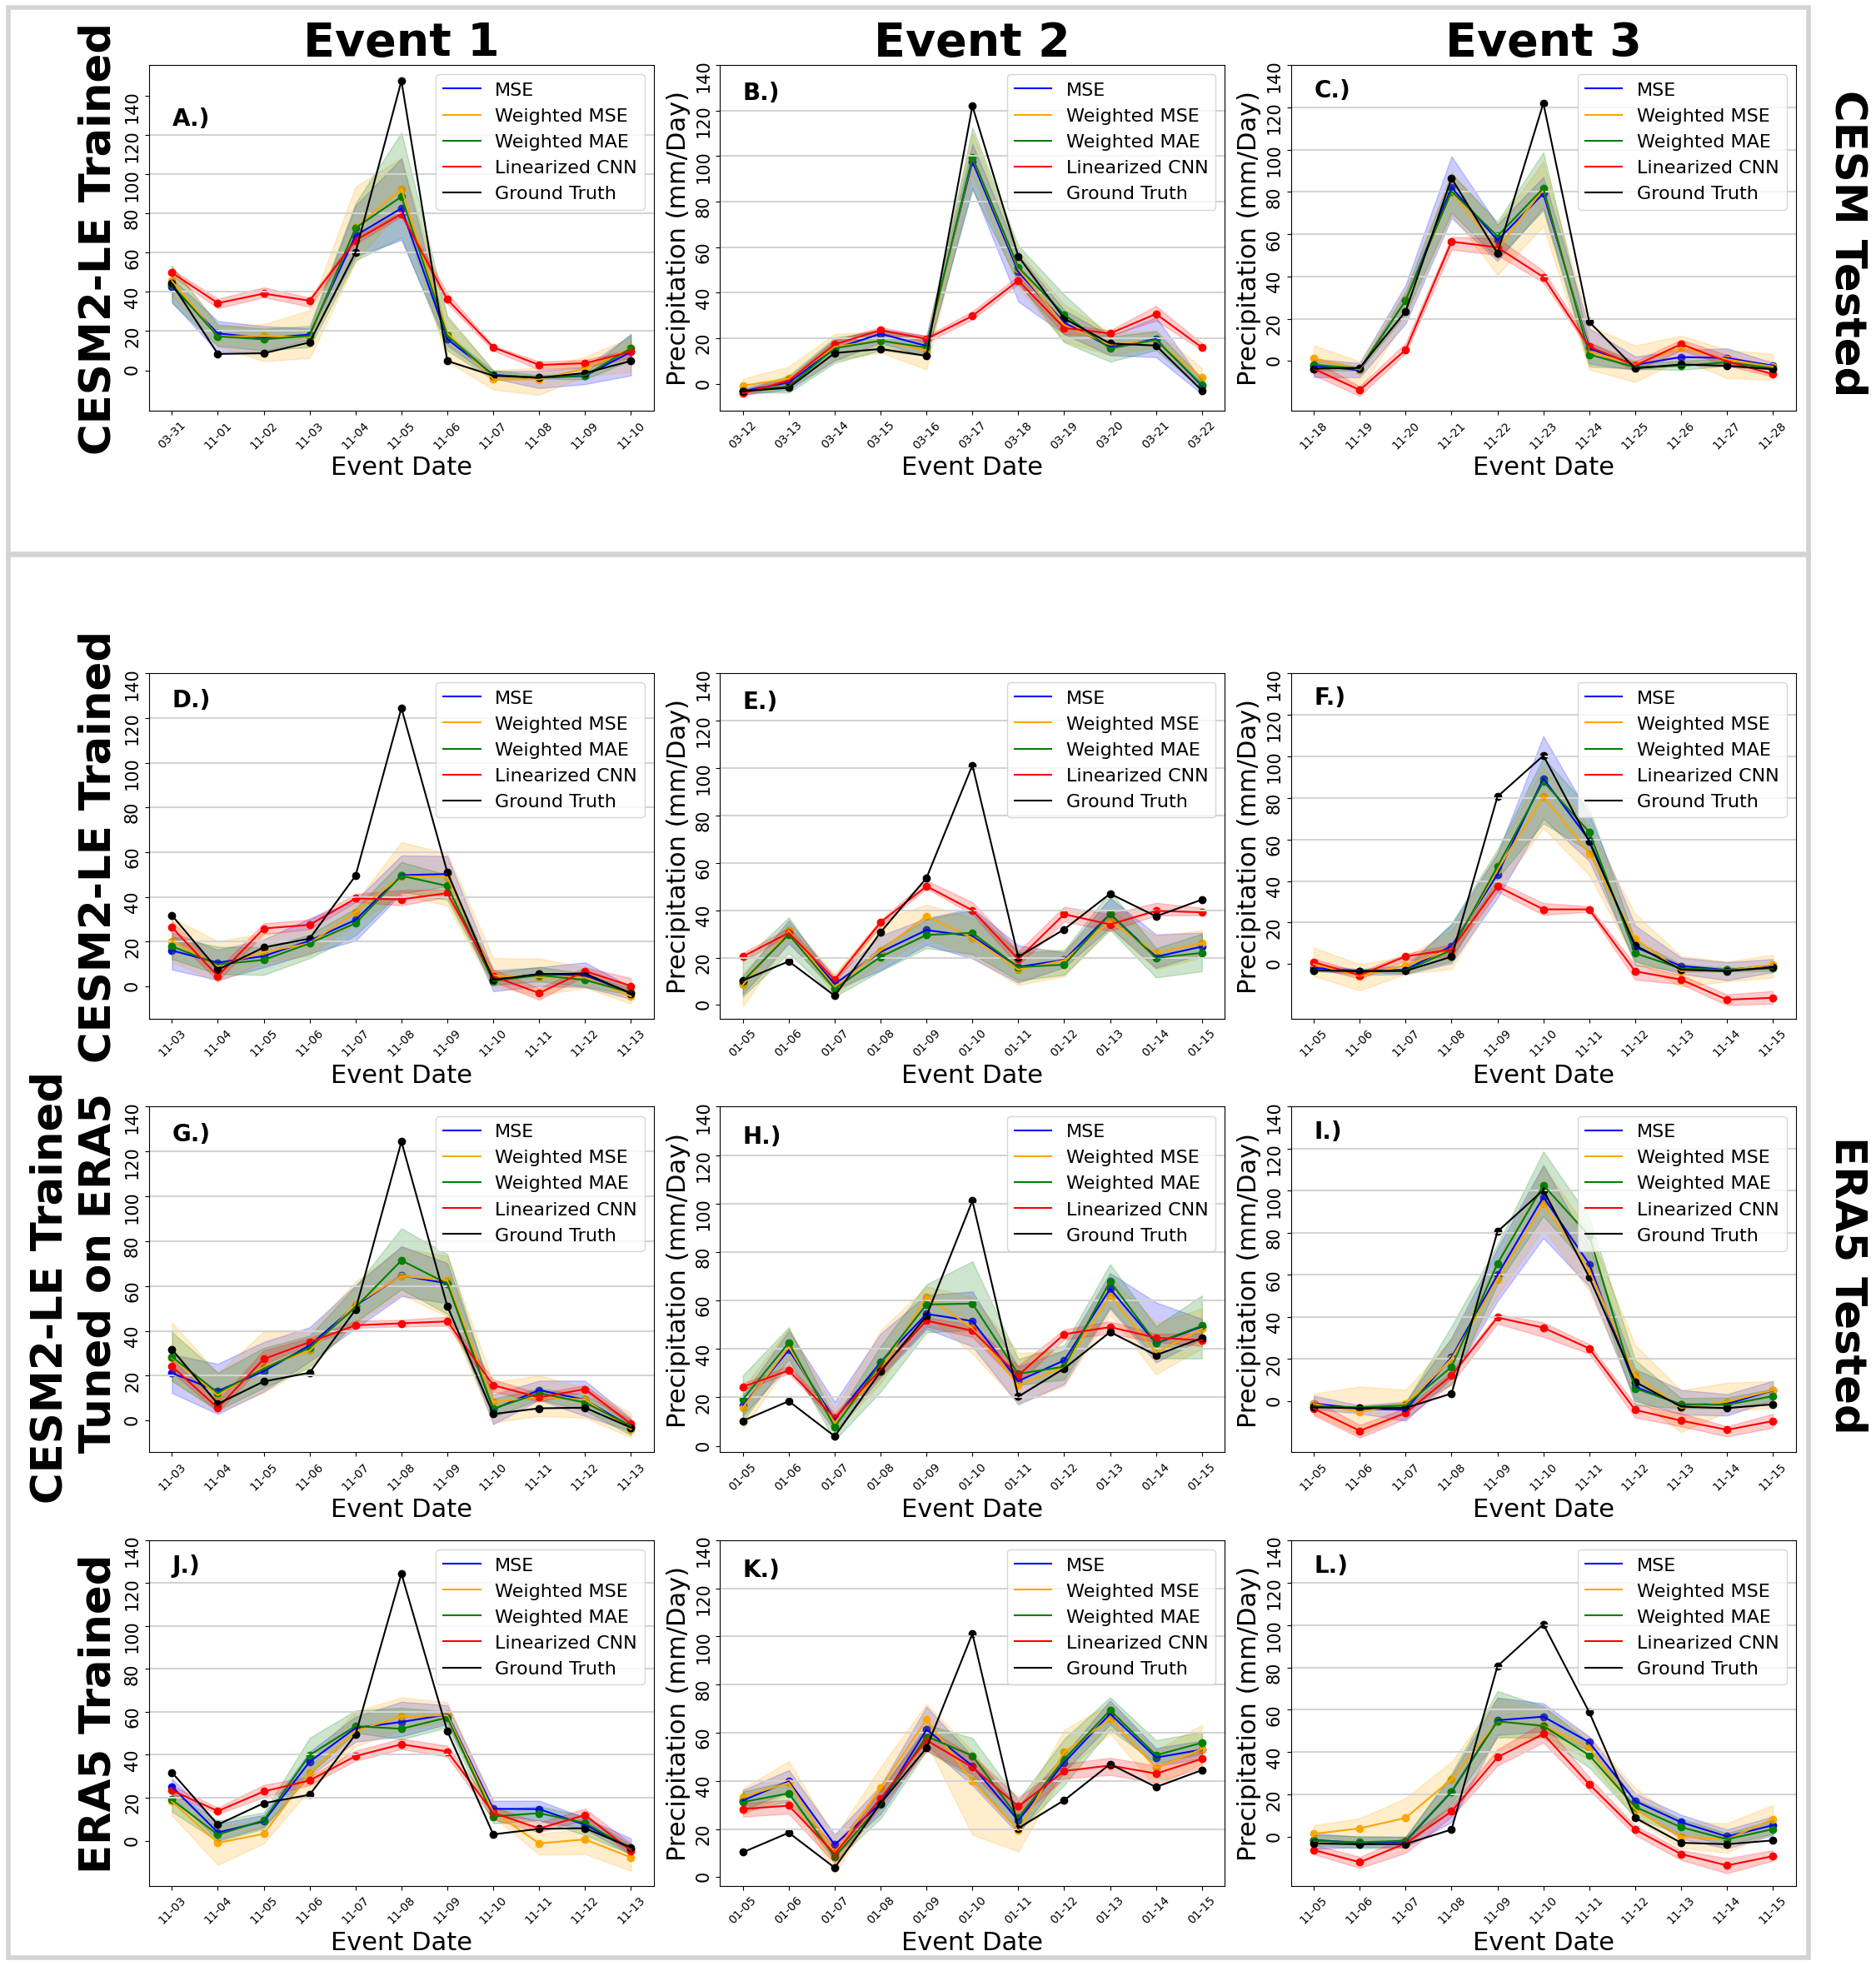

In [21]:
import matplotlib.gridspec as gridspec

j = 0
fig = plt.figure(figsize=(21.5, 24.5))

# Insert a spacer row after the first row
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.25, 1, 1, 1])

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5',
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']

colors = ['blue', 'orange', 'green', 'red']
event_names = ['Event 1', 'Event 2', 'Event 3']
model_type_names = ['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN']
events = [2, 6, 7]
loc = 'se'

for num1, direct in enumerate(dirs):
    for num2, event in enumerate(events):
        # Calculate grid position with spacer row after row 1
        row = j // 3
        col = j % 3
        row_in_grid = row if row == 0 else row + 1
        ax = plt.subplot(gs[row_in_grid, col])
        j += 1

        for num3, model_type in enumerate(model_types):
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}']
            idx2 = df['Y_max_test'].nlargest(event).iloc[-1]
            index = df[df['Y_max_test'] == idx2].index[0]

            if datasets[num1] == 'cesm':
                df1 = df
                df2 = locals()[f'df_{loc}_{datasets[num1]}']
                df = df.join(df2.reset_index(), how='inner')
            else:
                df2 = locals()[f'df_{loc}_{datasets[num1]}'][8000:]
                df = df.join(df2.reset_index(), how='inner')

            df_sub = df.iloc[max(index-5, 0): min(index+6, len(df))]
            mean = df_sub[columns_to_analyze].mean(axis=1).values
            mini = df_sub[columns_to_analyze].min(axis=1).values
            maxi = df_sub[columns_to_analyze].max(axis=1).values
            true = df_sub['Y_max_test'].values
            dates = np.array([x.split(' ')[0] for x in df_sub['Datetimes'].values])
            dates = [date[5:] for date in dates]

            plt.plot(dates, mean, color=colors[num3], label=model_type_names[num3])
            plt.scatter(dates, mean, color=colors[num3], label=None)
            plt.fill_between(dates, y1=mini, y2=maxi, color=colors[num3], alpha=0.2, label=None)

        plt.plot(dates, true, color='k', label='Ground Truth')
        plt.scatter(dates, true, color='k', label=None)

        plt.xlabel('Event Date', fontsize=22)
        plt.ylabel('Precipitation (mm/Day)', fontsize=22)
        plt.yticks(np.arange(0, 150, 20), np.arange(0, 150, 20), fontsize=15, rotation=90)
        plt.xticks(fontsize=10, rotation=45)
        plt.legend(fontsize=16, loc='upper right')
        plt.axhline(20, color='lightgrey',  zorder=1)
        plt.axhline(40, color='lightgrey',  zorder=1)
        plt.axhline(60, color='lightgrey',  zorder=1)
        plt.axhline(80, color='lightgrey',  zorder=1)
        plt.axhline(100, color='lightgrey',  zorder=1)
        plt.axhline(120, color='lightgrey',  zorder=1)

        plt.text(0, 125, f'{abc[j-1]}.)',  color='k', fontsize=20, fontweight='bold')

        if j <= 3:
            plt.title(f'{event_names[num2]}', fontsize=40).set_weight('bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37).set_weight('bold')
            
# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.13, cesm_bbox.y0 - 0.03),
    cesm_bbox.width + 0.23,
    cesm_bbox.height + 0.11,
    linewidth=4,
    edgecolor='lightgrey',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.11, cesm_bbox.y1 + 0.04, 'CESM Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.13, era5_bbox.y0 - 0.29),
    era5_bbox.width + 0.23,
    era5_bbox.height + 0.345,
    linewidth=4,
    edgecolor='lightgrey',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.11, era5_bbox.y1 - 0.23, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{loc}_precip_ts.png', format='png', dpi=500, bbox_inches='tight')


## First-Order CDF Investigation

In [12]:
locs = ['se', 'gp', 'ca']
dirs = ['pre', 'pre', 'post', 'brute']
datasets = ['cesm', 'era5', 'era5', 'era5']
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']

for num1, direct in enumerate(dirs):
    
    for num2, loc in enumerate(locs):

        for model_type in model_types:

            model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/{direct}/{loc}_max_precip_{model_type}_model*')
            
            for num4 in range(locals()[f'x_test_{datasets[num1]}'].shape[-1]):

                for num3, model_path in enumerate(model_list):

                    if model_type == 'weight_mse' or model_type == 'line':
                        model = load_model(f"{model_path}", compile=False)

                    else:
                        model = load_model(f"{model_path}", safe_mode=False)

                    arr = locals()[f'x_test_{datasets[num1]}'].copy()
                    arr[..., num4] = 0

                    locals()[f'y_pred{num3+1}'] = model.predict(arr, verbose=0).flatten()
                locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num4}'] = pd.DataFrame({'Y_max_test': locals()[f'y_{loc}_{datasets[num1]}_test'], 'y_pred1': y_pred1,
                                                                            'y_pred2': y_pred2, 'y_pred3': y_pred3, 'y_pred4': y_pred4,
                                                                            'y_pred5': y_pred5, 'y_pred6': y_pred6, 'y_pred7': y_pred7,
                                                                            'y_pred8': y_pred8, 'y_pred9': y_pred9, 'y_pred10': y_pred10})

                locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num4}'].to_csv(f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num4}'
                                                                                           , index=False)

I0000 00:00:1766804472.812621   66642 service.cc:146] XLA service 0x7fc41c008500 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766804472.812656   66642 service.cc:154]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1766804473.290010   66642 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


KeyError: 'df_pre_cesm_se_mse_0'

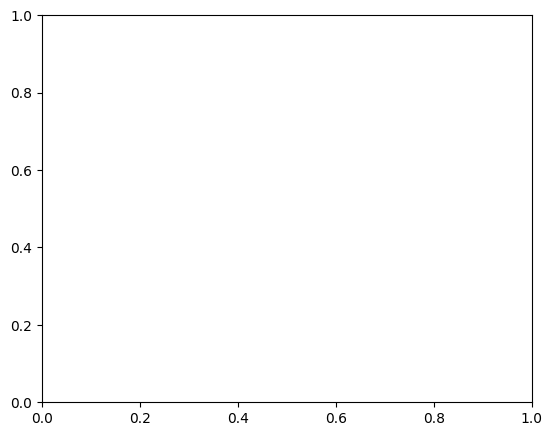

In [19]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(21.5, 24.5))

# Define a 5-row grid, where row 2 is just a spacer
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.2, 1, 1, 1])  # Extra space after first row

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5', 
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']

regions = ['Southeast', 'Great Plains', 'California']
info = ['CESM2-LE Trained', 'CESM2-LE Trained', 'CESM2-LE Trained \n Tuned on ERA5', 'ERA5 Trained']
abc = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']

axes = []

j = 0
for num1, direct in enumerate(dirs):
    for num2, loc in enumerate(locs):
        # Manually calculate grid index with extra spacer row after row 1
        row = j // 3
        col = j % 3
        if row == 1:
            ax = plt.subplot(gs[row + 1, col])  # Skip row 1 (the spacer)
        elif row > 1:
            ax = plt.subplot(gs[row + 1, col])  # Push down everything else
        else:
            ax = plt.subplot(gs[row, col])

        axes.append(ax)
        
        j += 1  # Only increment once per subplot

        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_0']
            vals = df[columns_to_analyze].mean(axis=1)

            if datasets[num1] == 'cesm':
                vals = cesm_retrend(vals, locals()[f'{loc}_polyfit'])
                y_max = cesm_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'{loc}_polyfit'])
            else:
                vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
                y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

            ecdf = stats.ecdf(vals)
            ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=3)

            locals()[f'r_{model_type}'] = r2_score(y_max, vals)

        ecdf = stats.ecdf(y_max)
        ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=4, color='k')

        ax.legend(['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN', 'Ground Truth'], fontsize=15, loc = 'upper right')
        ax.set_xlabel('Precipitation (mm/Day)', fontsize=22)
        ax.set_ylabel('Log of Probability', fontsize=22)
        ax.set_xticks(np.arange(0, 150, 20))
        ax.set_xticklabels(np.arange(0, 150, 20), fontsize=15)
        ax.set_yticks(np.arange(0, -5, -1))
        ax.set_yticklabels(['$10^{0}$', '$10^{-1}$', '$10^{-2}$', '$10^{-3}$', '$10^{-4}$'], fontsize=15)
        ax.grid()

        if j <= 3:
            ax.set_title(f'{regions[num2]}', fontsize=40, fontweight='bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_mse)[:4]}', (25, -4), textcoords="offset points",
            xytext=(0,65), ha='center', color='blue', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mse)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,45), ha='center', color='orange', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mae)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,25), ha='center', color='green', fontsize=20, fontweight='bold')
        
        ax.annotate(f'$R^2$: {str(r_line)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,5), ha='center', color='red', fontsize=20, fontweight='bold')
        
        ax.annotate(f'{abc[j-1]}.)', (25, 0), textcoords="offset points",  color='k', fontsize=20,
                    xytext=(-80, 20 + np.max(np.log10(1 - ecdf.cdf.probabilities))), ha='center',
                    bbox=dict(boxstyle='round', facecolor='w', alpha=1), fontweight='bold')
        

# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.09, cesm_bbox.y0 - 0.05),
    cesm_bbox.width + 0.11,
    cesm_bbox.height + 0.1,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.02, cesm_bbox.y1 + 0.01, 'CESM2-LE Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.09, era5_bbox.y0 - 0.22),
    era5_bbox.width + 0.11,
    era5_bbox.height + 0.255,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.02, era5_bbox.y1 - 0.18, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.savefig('cdfs0.png', format='png', dpi=500, bbox_inches='tight')


In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(21.5, 24.5))

# Define a 5-row grid, where row 2 is just a spacer
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.2, 1, 1, 1])  # Extra space after first row

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5', 
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']

regions = ['Southeast', 'Great Plains', 'California']

axes = []

j = 0
for num1, direct in enumerate(dirs):
    for num2, loc in enumerate(locs):
        # Manually calculate grid index with extra spacer row after row 1
        row = j // 3
        col = j % 3
        if row == 1:
            ax = plt.subplot(gs[row + 1, col])  # Skip row 1 (the spacer)
        elif row > 1:
            ax = plt.subplot(gs[row + 1, col])  # Push down everything else
        else:
            ax = plt.subplot(gs[row, col])

        axes.append(ax)
        
        j += 1  # Only increment once per subplot

        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_1']
            vals = df[columns_to_analyze].mean(axis=1)

            if datasets[num1] == 'cesm':
                vals = cesm_retrend(vals, locals()[f'{loc}_polyfit'])
                y_max = cesm_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'{loc}_polyfit'])
            else:
                vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
                y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

            ecdf = stats.ecdf(vals)
            ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=3)

            locals()[f'r_{model_type}'] = r2_score(y_max, vals)

        ecdf = stats.ecdf(y_max)
        ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=4, color='k')

        ax.legend(['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN', 'Ground Truth'], fontsize=15, loc = 'upper right')
        ax.set_xlabel('Precipitation (mm/Day)', fontsize=22)
        ax.set_ylabel('Log of Probability', fontsize=22)
        ax.set_xticks(np.arange(0, 150, 20))
        ax.set_xticklabels(np.arange(0, 150, 20), fontsize=15)
        ax.set_yticks(np.arange(0, -5, -1))
        ax.set_yticklabels(['$10^{0}$', '$10^{-1}$', '$10^{-2}$', '$10^{-3}$', '$10^{-4}$'], fontsize=15)
        ax.grid()

        if j <= 3:
            ax.set_title(f'{regions[num2]}', fontsize=40, fontweight='bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_mse)[:4]}', (25, -4), textcoords="offset points",
            xytext=(0,65), ha='center', color='blue', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mse)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,45), ha='center', color='orange', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mae)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,25), ha='center', color='green', fontsize=20, fontweight='bold')
        
        ax.annotate(f'$R^2$: {str(r_line)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,5), ha='center', color='red', fontsize=20, fontweight='bold')

        ax.annotate(f'{abc[j-1]}.)', (25, 0), textcoords="offset points",  color='k', fontsize=20,
                    xytext=(-80, 20 + np.max(np.log10(1 - ecdf.cdf.probabilities))), ha='center',
                    bbox=dict(boxstyle='round', facecolor='w', alpha=1), fontweight='bold')
        

# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.09, cesm_bbox.y0 - 0.05),
    cesm_bbox.width + 0.11,
    cesm_bbox.height + 0.1,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.02, cesm_bbox.y1 + 0.01, 'CESM2-LE Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.09, era5_bbox.y0 - 0.22),
    era5_bbox.width + 0.11,
    era5_bbox.height + 0.255,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.02, era5_bbox.y1 - 0.18, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.savefig('cdfs1.png', format='png', dpi=500, bbox_inches='tight')


In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(21.5, 24.5))

# Define a 5-row grid, where row 2 is just a spacer
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.2, 1, 1, 1])  # Extra space after first row

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5', 
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']

regions = ['Southeast', 'Great Plains', 'California']
#info = ['CESM Only', 'ERA5 on CESM', 'Tuned ERA5', 'ERA5 Only']

axes = []

j = 0
for num1, direct in enumerate(dirs):
    for num2, loc in enumerate(locs):
        # Manually calculate grid index with extra spacer row after row 1
        row = j // 3
        col = j % 3
        if row == 1:
            ax = plt.subplot(gs[row + 1, col])  # Skip row 1 (the spacer)
        elif row > 1:
            ax = plt.subplot(gs[row + 1, col])  # Push down everything else
        else:
            ax = plt.subplot(gs[row, col])

        axes.append(ax)

        j += 1  # Only increment once per subplot

        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_2']
            vals = df[columns_to_analyze].mean(axis=1)

            if datasets[num1] == 'cesm':
                vals = cesm_retrend(vals, locals()[f'{loc}_polyfit'])
                y_max = cesm_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'{loc}_polyfit'])
            else:
                vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
                y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

            ecdf = stats.ecdf(vals)
            ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=3)

            locals()[f'r_{model_type}'] = r2_score(y_max, vals)

        ecdf = stats.ecdf(y_max)
        ax.plot(ecdf.cdf.quantiles, np.log10(1 - ecdf.cdf.probabilities), lw=4, color='k')

        ax.legend(['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized CNN', 'Ground Truth'], fontsize=15, loc = 'upper right')
        ax.set_xlabel('Precipitation (mm/Day)', fontsize=22)
        ax.set_ylabel('Log of Probability', fontsize=22)
        ax.set_xticks(np.arange(0, 150, 20))
        ax.set_xticklabels(np.arange(0, 150, 20), fontsize=15)
        ax.set_yticks(np.arange(0, -5, -1))
        ax.set_yticklabels(['$10^{0}$', '$10^{-1}$', '$10^{-2}$', '$10^{-3}$', '$10^{-4}$'], fontsize=15)
        ax.grid()

        if j <= 3:
            ax.set_title(f'{regions[num2]}', fontsize=40, fontweight='bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_mse)[:4]}', (25, -4), textcoords="offset points",
            xytext=(0,65), ha='center', color='blue', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mse)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,45), ha='center', color='orange', fontsize=20, fontweight='bold')

        ax.annotate(f'$R^2$: {str(r_weight_mae)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,25), ha='center', color='green', fontsize=20, fontweight='bold')
        
        ax.annotate(f'$R^2$: {str(r_line)[:4]}', (25, -4), textcoords="offset points",
                    xytext=(0,5), ha='center', color='red', fontsize=20, fontweight='bold')

        ax.annotate(f'{abc[j-1]}.)', (25, 0), textcoords="offset points",  color='k', fontsize=20,
                    xytext=(-80, 20 + np.max(np.log10(1 - ecdf.cdf.probabilities))), ha='center',
                    bbox=dict(boxstyle='round', facecolor='w', alpha=1), fontweight='bold')
        

# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.09, cesm_bbox.y0 - 0.05),
    cesm_bbox.width + 0.11,
    cesm_bbox.height + 0.1,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.02, cesm_bbox.y1 + 0.01, 'CESM2-LE Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.09, era5_bbox.y0 - 0.22),
    era5_bbox.width + 0.11,
    era5_bbox.height + 0.255,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.02, era5_bbox.y1 - 0.18, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.savefig('cdfs2.png', format='png', dpi=500, bbox_inches='tight')


## Time Sync

In [23]:
def complex_method(df_cur, df_test, datatype):
    '''
    A definition that generates results for the temporal skill of the CNNs.
    
    df_cur = the dataframe that is being tested
    df_test = the testing dataframe
    
    '''
    
    if datatype == 'cesm':
        df_test = df_test.reset_index()
    
    else:
        df_test = df_test[8000:]
        df_test = df_test.reset_index()
    
    #join the dataframe with the testing dataframe
    join = df_cur.join(df_test, how='inner')
    join['Datetimes'] = pd.to_datetime(join['Datetimes'])
    
    #set vars
    columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5', 
                          'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']
    quants = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

    #create pandas df
    df = pd.DataFrame({'quants': quants})
    
    #iterate through the quantiles
    for col in columns_to_analyze:
        temp = []
        
        for quant in quants:
            df1 = join.nlargest(int(len(join)*quant), 'Y_max_test').sort_index()
            val = []

            for rid, row in df1.iterrows():
                start_date = row.Datetimes - pd.Timedelta(days=5)
                end_date = row.Datetimes + pd.Timedelta(days=5)

                df_work = join[(join['Datetimes'] >= start_date) & (join['Datetimes'] <= end_date)].copy()
                
                val_idx = np.where(df_work['Y_max_test'].values == row.Y_max_test)[0][0]

                if val_idx in np.where(df_work[col].values >= 0.8*row.Y_max_test)[0]:
                    val.append(0)

                else:
                    val.append(np.where(df_work[col].values == np.max(df_work[col].values))[0][0]-val_idx)

            temp.append(np.sum(np.mean(np.absolute(val))))

        df[col] = temp

    return df
    

NameError: name 'complex_method' is not defined

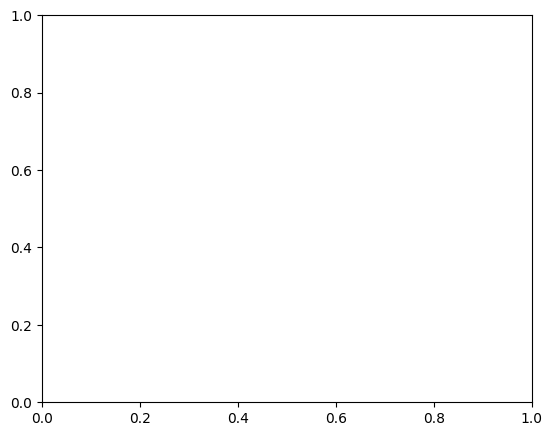

In [79]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(21.5, 24.5))

# Define a 5-row grid, where row 2 is just a spacer
gs = gridspec.GridSpec(5, 3, height_ratios=[1, 0.2, 1, 1, 1])  # Extra space after first row

columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5', 
                      'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']

regions = ['Southeast', 'Great Plains', 'California']
columns_to_analyze = ['y_pred1', 'y_pred2', 'y_pred3', 'y_pred4', 'y_pred5', 
                          'y_pred6', 'y_pred7', 'y_pred8', 'y_pred9', 'y_pred10']
quants = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]


j = 0
for num1, direct in enumerate(dirs):
    for num2, loc in enumerate(locs):
        # Manually calculate grid index with extra spacer row after row 1
        row = j // 3
        col = j % 3
        if row == 1:
            ax = plt.subplot(gs[row + 1, col])  # Skip row 1 (the spacer)
        elif row > 1:
            ax = plt.subplot(gs[row + 1, col])  # Push down everything else
        else:
            ax = plt.subplot(gs[row, col])
        
        j += 1  # Only increment once per subplot

        for model_type in model_types:

            df = complex_method(locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}'],
                                locals()[f'df_{loc}_{datasets[num1]}'], datasets[num1])

            mean = df[columns_to_analyze].mean(axis=1).values
            mini = df[columns_to_analyze].min(axis=1).values
            maxi = df[columns_to_analyze].max(axis=1).values

            ax.plot(quants, mean, lw=2)
            ax.fill_between(quants, y1 = mini, y2 = maxi, alpha=0.2)

        ax.set_xlabel('Quantile Value', fontsize=22).set_weight('bold')
        ax.set_ylabel('Days Difference', fontsize=22).set_weight('bold')
        ax.set_xticks(quants, [x + '%' for x in map(str, (np.array(quants)*100).astype(int))], fontsize=12)
        ax.grid()
        
        if j <= 3:
            ax.set_title(f'{regions[num2]}', fontsize=40, fontweight='bold')
        if num2 == 0:
            ax.set_ylabel(f'{info[num1]}', fontsize=37, fontweight='bold')

            

# === Add rectangle for CESM (top row) ===
fig.canvas.draw()  # Needed to get accurate positions
renderer = fig.canvas.get_renderer()

# Get the bounding boxes of the CESM and ERA5 panels
cesm_bbox = Bbox.union([axes[0].get_position(), axes[1].get_position(), axes[2].get_position()])
era5_bbox = Bbox.union([
    axes[3].get_position(), axes[4].get_position(), axes[5].get_position(),
    axes[6].get_position(), axes[7].get_position(), axes[8].get_position()
])

# Draw rectangle for CESM
rect_cesm = patches.Rectangle(
    (cesm_bbox.x0 - 0.09, cesm_bbox.y0 - 0.05),
    cesm_bbox.width + 0.11,
    cesm_bbox.height + 0.1,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_cesm)
fig.text(cesm_bbox.x1 + 0.02, cesm_bbox.y1 - 0.01, 'CESM Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

# Draw rectangle for ERA5
rect_era5 = patches.Rectangle(
    (era5_bbox.x0 - 0.09, era5_bbox.y0 - 0.22),
    era5_bbox.width + 0.11,
    era5_bbox.height + 0.255,
    linewidth=4,
    edgecolor='black',
    facecolor='none',
    transform=fig.transFigure,
    zorder=1000,
)
fig.patches.append(rect_era5)
fig.text(era5_bbox.x1 + 0.02, era5_bbox.y1 - 0.18, 'ERA5 Tested', fontsize=37, va='top', ha='left', weight='bold', rotation=270)

plt.savefig('time_sync.png', format='png', dpi=500, bbox_inches='tight')


## Zero Tables

In [18]:
from matplotlib import colors
import matplotlib.cm as cm

num1 = 1
direct = dirs[num1]
variables = ['CWV', 'Z500', 'TAS']
regions = ['Southeast', 'Great Plains', 'California']

data_values = []

for num2, loc in enumerate(locs):
    for num3, var in enumerate(variables): 
        rs = []
        
        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num3}']
            vals = df[columns_to_analyze].mean(axis=1)

            vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
            y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

            rs.append(r2_score(y_max, vals))
        data_values.append(rs)
            
# Build data for table
data = []
region_labels = []
for i in range(len(data_values)):
    # Add region label every 3 rows
    if i % 3 == 0:
        region_labels.append(regions[i // 3])
    else:
        region_labels.append('')
    data.append([region_labels[i], variables[i % 3]] + data_values[i])
    
column_colors = ['#1f77b4', '#1f77b4', '#ffbf00', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# Column headers
column_labels = ['Region', 'Zero Variable',
                 r'$R^2$ - MSE',
                 r'$R^2$ - Weighted MSE',
                 r'$R^2$ - Weighted MAE',
                 r'$R^2$ - Linearized CNN']

# Convert data values to strings (for display), keeping numbers to color code later
cell_text = []
cell_colors = []
cmap = plt.cm.Blues_r
norm = colors.Normalize(vmin=0, vmax=1)

for row in data:
    row_text = row[:2]  # Region and Variable
    row_colors = ['white', 'white']
    for val in row[2:]:
        row_text.append(f"{val:.2f}")
        row_colors.append(cmap(norm(val)))
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Plot
fig, ax = plt.subplots(figsize=(20, 7))
ax.axis('off')

# Create table
the_table = ax.table(
    cellText=cell_text,
    colLabels=column_labels,
    cellColours=cell_colors,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Format font size
the_table.auto_set_font_size(False)
the_table.set_fontsize(14)
the_table.scale(1, 2.5)

# Bold headers
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
        if col not in [0,1]:
            cell.get_text().set_color(column_colors[col - 1])
            
    if col == 0 and cell.get_text().get_text() != '':
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
    if col == 1 and cell.get_text().get_text() in ['CWV', 'Z500','TAS']:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
    if row != 0 and col > 1:
        cell.get_text().set_color('white' if float(cell.get_text().get_text()) < 0.4 else 'black')
        cell.get_text().set_weight('bold')
        cell.set_fontsize(16)
        
for i in [1,4,7]:
    the_table[i, 0].visible_edges = 'LTR'  # No bottom line
for i in [2,9]:
    the_table[i, 0].visible_edges = 'LBR'  # No top line
for i in [2,3,5,6,8]:
    the_table[i, 0].visible_edges = 'LR'  # No bottom line

        
# Add a colorbar under the table
cax = fig.add_axes([0.1, 0.12, 0.8, 0.05])  # [left, bottom, width, height]
cb1 = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                   cax=cax,
                   orientation='horizontal')
cb1.set_ticks(np.arange(0, 1.01, 0.2))
cb1.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
cb1.ax.tick_params(labelsize=20)
cb1.set_label('R² Value', fontsize=25)
plt.suptitle('CESM Trained, ERA5 Tested Table', size=35).set_weight('bold')

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room for the colorbar
plt.show()

plt.savefig(f'zeros_table.png', format='png', dpi=500, bbox_inches='tight')
        

KeyError: 'df_pre_era5_se_mse_0'

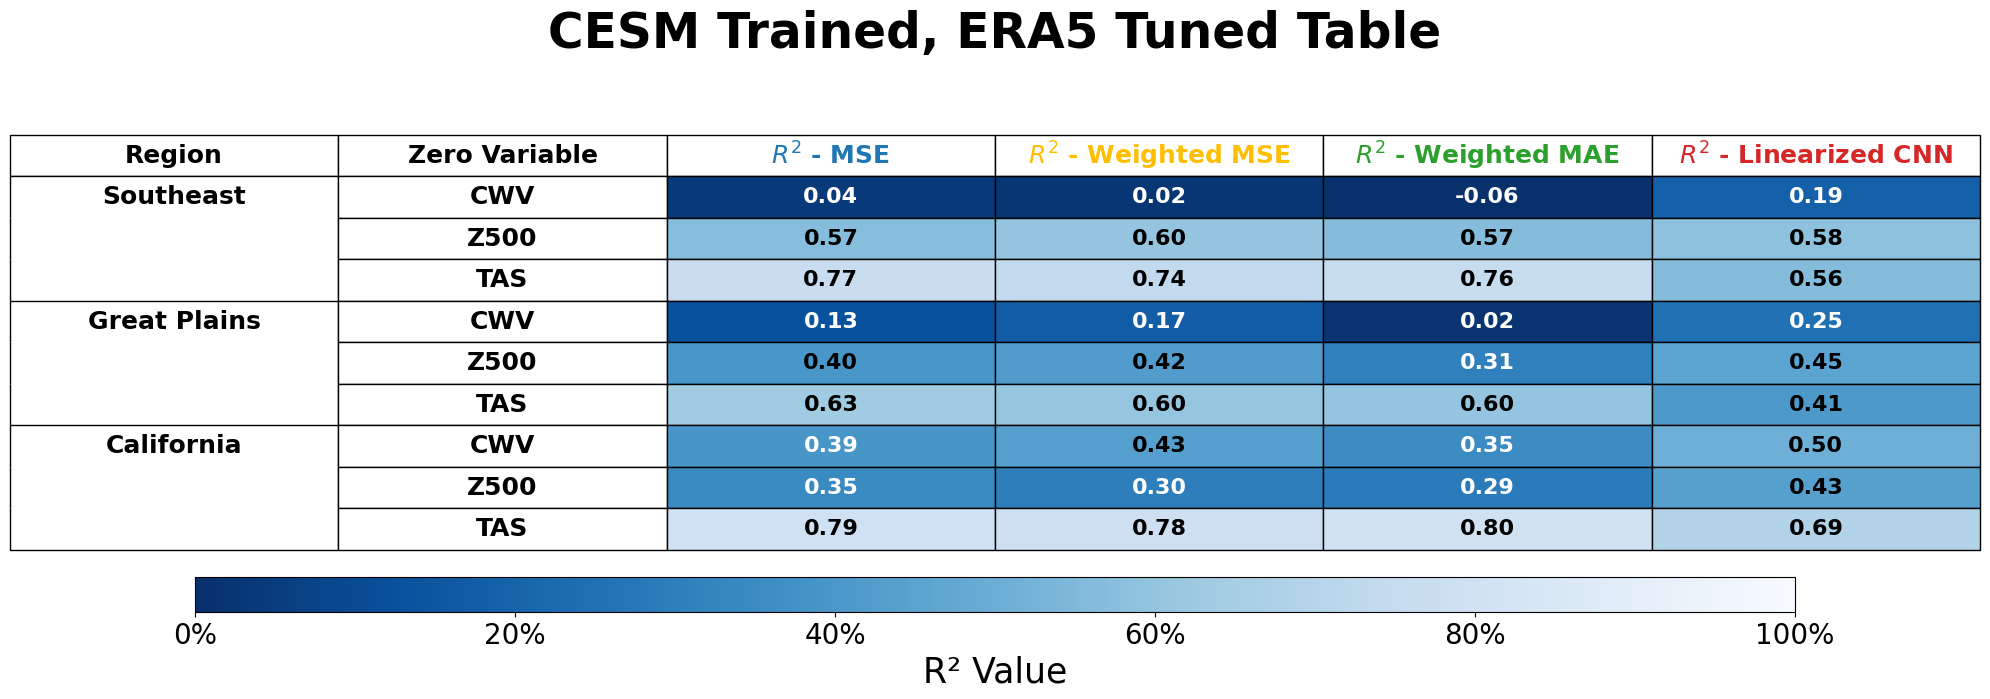

In [26]:
num1 = 2
direct = dirs[num1]
variables = ['CWV', 'Z500', 'TAS']
regions = ['Southeast', 'Great Plains', 'California']

data_values = []

for num2, loc in enumerate(locs):
    for num3, var in enumerate(variables): 
        rs = []
        
        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num3}']
            vals = df[columns_to_analyze].mean(axis=1)

            vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
            y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

            rs.append(r2_score(y_max, vals))
        data_values.append(rs)
            
# Build data for table
data = []
region_labels = []
for i in range(len(data_values)):
    # Add region label every 3 rows
    if i % 3 == 0:
        region_labels.append(regions[i // 3])
    else:
        region_labels.append('')
    data.append([region_labels[i], variables[i % 3]] + data_values[i])
    
column_colors = ['#1f77b4', '#1f77b4', '#ffbf00', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# Column headers
column_labels = ['Region', 'Zero Variable',
                 r'$R^2$ - MSE',
                 r'$R^2$ - Weighted MSE',
                 r'$R^2$ - Weighted MAE',
                 r'$R^2$ - Linearized CNN']

# Convert data values to strings (for display), keeping numbers to color code later
cell_text = []
cell_colors = []
cmap = plt.cm.Blues_r
norm = colors.Normalize(vmin=0, vmax=1)

for row in data:
    row_text = row[:2]  # Region and Variable
    row_colors = ['white', 'white']
    for val in row[2:]:
        row_text.append(f"{val:.2f}")
        row_colors.append(cmap(norm(val)))
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Plot
fig, ax = plt.subplots(figsize=(20, 7))
ax.axis('off')

# Create table
the_table = ax.table(
    cellText=cell_text,
    colLabels=column_labels,
    cellColours=cell_colors,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Format font size
the_table.auto_set_font_size(False)
the_table.set_fontsize(14)
the_table.scale(1, 2.5)

# Bold headers
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
        if col not in [0,1]:
            cell.get_text().set_color(column_colors[col - 1])
    if col == 0 and cell.get_text().get_text() != '':
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if col == 1 and cell.get_text().get_text() in ['CWV', 'Z500','TAS']:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if row != 0 and col > 1:
        cell.get_text().set_color('white' if float(cell.get_text().get_text()) < 0.4 else 'black')
        cell.get_text().set_weight('bold')
        cell.set_fontsize(16)
        
for i in [1,4,7]:
    the_table[i, 0].visible_edges = 'LTR'  # No bottom line
for i in [2,9]:
    the_table[i, 0].visible_edges = 'LBR'  # No top line
for i in [2,3,5,6,8]:
    the_table[i, 0].visible_edges = 'LR'  # No bottom line

        
# Add a colorbar under the table
cax = fig.add_axes([0.1, 0.12, 0.8, 0.05])  # [left, bottom, width, height]
cb1 = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                   cax=cax,
                   orientation='horizontal')
cb1.set_ticks(np.arange(0, 1.01, 0.2))
cb1.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
cb1.ax.tick_params(labelsize=20)
cb1.set_label('R² Value', fontsize=25)

plt.suptitle('CESM Trained, ERA5 Tuned Table', size=35).set_weight('bold')

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room for the colorbar
  
plt.savefig(f'finetune_table.png', format='png', dpi=500, bbox_inches='tight')

plt.show()

In [ ]:
num1 = 3
direct = dirs[num1]
variables = ['CWV', 'Z500', 'TAS']
regions = ['Southeast', 'Great Plains', 'California']

data_values = []

for num2, loc in enumerate(locs):
    for num3, var in enumerate(variables): 
        rs = []
        
        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num3}']
            vals = df[columns_to_analyze].mean(axis=1)

            vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
            y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

            rs.append(r2_score(y_max, vals))
        data_values.append(rs)
        
data_values1 = data_values
            
# Build data for table
data = []
region_labels = []
for i in range(len(data_values)):
    # Add region label every 3 rows
    if i % 3 == 0:
        region_labels.append(regions[i // 3])
    else:
        region_labels.append('')
    data.append([region_labels[i], variables[i % 3]] + data_values[i])
    
column_colors = ['#1f77b4', '#1f77b4', '#ffbf00', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# Column headers
column_labels = ['Region', 'Zero Variable',
                 r'$R^2$ - MSE',
                 r'$R^2$ - Weighted MSE',
                 r'$R^2$ - Weighted MAE',
                 r'$R^2$ - Linearized CNN']

# Convert data values to strings (for display), keeping numbers to color code later
cell_text = []
cell_colors = []
cmap = plt.cm.Blues_r
norm = colors.Normalize(vmin=0, vmax=1)

for row in data:
    row_text = row[:2]  # Region and Variable
    row_colors = ['white', 'white']
    for val in row[2:]:
        row_text.append(f"{val:.2f}")
        row_colors.append(cmap(norm(val)))
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Plot
fig, ax = plt.subplots(figsize=(20, 7))
ax.axis('off')

# Create table
the_table = ax.table(
    cellText=cell_text,
    colLabels=column_labels,
    cellColours=cell_colors,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Format font size
the_table.auto_set_font_size(False)
the_table.set_fontsize(14)
the_table.scale(1, 2.5)

# Bold headers
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
        if col not in [0,1]:
            cell.get_text().set_color(column_colors[col - 1])
    if col == 0 and cell.get_text().get_text() != '':
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if col == 1 and cell.get_text().get_text() in ['CWV', 'Z500','TAS']:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if row != 0 and col > 1:
        cell.get_text().set_color('white' if float(cell.get_text().get_text()) < 0.4 else 'black')
        cell.get_text().set_weight('bold')
        cell.set_fontsize(16)
        

for i in [1,4,7]:
    the_table[i, 0].visible_edges = 'LTR'  # No bottom line
for i in [2,9]:
    the_table[i, 0].visible_edges = 'LBR'  # No top line
for i in [2,3,5,6,8]:
    the_table[i, 0].visible_edges = 'LR'  # No bottom line

        
# Add a colorbar under the table
cax = fig.add_axes([0.1, 0.12, 0.8, 0.05])  # [left, bottom, width, height]
cb1 = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                   cax=cax,
                   orientation='horizontal')
cb1.set_ticks(np.arange(0, 1.01, 0.2))
cb1.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
cb1.ax.tick_params(labelsize=20)
cb1.set_label('R² Value', fontsize=25)

plt.suptitle('ERA5 Only Table', size=35).set_weight('bold')

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room for the colorbar
plt.show()
  
        

In [ ]:
num1 = 1
direct = dirs[num1]
variables = ['CWV', 'Z500', 'TAS']
regions = ['Southeast', 'Great Plains', 'California']
column_colors = ['#1f77b4', '#1f77b4', '#ffbf00', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
data_values = []

for num2, loc in enumerate(locs):
    for num3, var in enumerate(variables): 
        row = []
        
        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num3}']
            rs = []
            for col in columns_to_analyze:
                vals = df[col].values

                vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
                y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

                rs.append(r2_score(y_max, vals))
            row.append(f'{np.min(rs):.2f} - {np.max(rs):.2f}')
        data_values.append(row)
            
# Build data for table
data = []
region_labels = []
for i in range(len(data_values)):
    # Add region label every 3 rows
    if i % 3 == 0:
        region_labels.append(regions[i // 3])
    else:
        region_labels.append('')
    data.append([region_labels[i], variables[i % 3]] + data_values[i])
    
# Column headers
column_labels = ['Region', 'Zero Variable',
                 r'$R^2$ - MSE',
                 r'$R^2$ - Weighted MSE',
                 r'$R^2$ - Weighted MAE',
                 r'$R^2$ - Linearized CNN']

# Convert data values to strings (for display), keeping numbers to color code later
cell_text = []
cell_colors = []
cmap = plt.cm.Blues_r
norm = colors.Normalize(vmin=0, vmax=1)

for row in data:
    row_text = row[:2]  # Region and Variable
    row_colors = ['white', 'white']
    for val in row[2:]:
        row_text.append(f"{val}")
        row_colors.append(cmap(norm(np.mean([float(val.split()[0]), float(val.split()[2])]))))
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Plot
fig, ax = plt.subplots(figsize=(20, 7))
ax.axis('off')

# Create table
the_table = ax.table(
    cellText=cell_text,
    colLabels=column_labels,
    cellColours=cell_colors,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Format font size
the_table.auto_set_font_size(False)
the_table.set_fontsize(14)
the_table.scale(1, 2.5)

# Bold headers
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
        if col not in [0,1]:
            cell.get_text().set_color(column_colors[col - 1])
    if col == 0 and cell.get_text().get_text() != '':
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if col == 1 and cell.get_text().get_text() in ['CWV', 'Z500','TAS']:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if row != 0 and col > 1:
        #cell.get_text().set_color('white' if float(np.array(data_values1)[col, row]) > 0.6 else 'black')
        cell.get_text().set_weight('bold')
        cell.set_fontsize(16)
        
for i in [1,4,7]:
    the_table[i, 0].visible_edges = 'LTR'  # No bottom line
for i in [2,9]:
    the_table[i, 0].visible_edges = 'LBR'  # No top line
for i in [2,3,5,6,8]:
    the_table[i, 0].visible_edges = 'LR'  # No bottom line


# Add a colorbar under the table
cax = fig.add_axes([0.1, 0.12, 0.8, 0.05])  # [left, bottom, width, height]
cb1 = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                   cax=cax,
                   orientation='horizontal')
cb1.set_ticks(np.arange(0, 1.01, 0.2))
cb1.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
cb1.ax.tick_params(labelsize=20)
cb1.set_label('Mean R² Value', fontsize=25)

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room for the colorbar
plt.show()
  
        

In [ ]:
num1 = 2
direct = dirs[num1]
variables = ['CWV', 'Z500', 'TAS']
regions = ['Southeast', 'Great Plains', 'California']
column_colors = ['#1f77b4', '#1f77b4', '#ffbf00', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
data_values = []

for num2, loc in enumerate(locs):
    for num3, var in enumerate(variables): 
        row = []
        
        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num3}']
            rs = []
            for col in columns_to_analyze:
                vals = df[col].values

                vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
                y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

                rs.append(r2_score(y_max, vals))
            row.append(f'{np.min(rs):.2f} - {np.max(rs):.2f}')
        data_values.append(row)
            
# Build data for table
data = []
region_labels = []
for i in range(len(data_values)):
    # Add region label every 3 rows
    if i % 3 == 0:
        region_labels.append(regions[i // 3])
    else:
        region_labels.append('')
    data.append([region_labels[i], variables[i % 3]] + data_values[i])
    
# Column headers
column_labels = ['Region', 'Zero Variable',
                 r'$R^2$ - MSE',
                 r'$R^2$ - Weighted MSE',
                 r'$R^2$ - Weighted MAE',
                 r'$R^2$ - Linearized CNN']

# Convert data values to strings (for display), keeping numbers to color code later
cell_text = []
cell_colors = []
cmap = plt.cm.Blues_r
norm = colors.Normalize(vmin=0, vmax=1)

for row in data:
    row_text = row[:2]  # Region and Variable
    row_colors = ['white', 'white']
    for val in row[2:]:
        row_text.append(f"{val}")
        row_colors.append(cmap(norm(np.mean([float(val.split()[0]), float(val.split()[2])]))))
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Plot
fig, ax = plt.subplots(figsize=(20, 7))
ax.axis('off')

# Create table
the_table = ax.table(
    cellText=cell_text,
    colLabels=column_labels,
    cellColours=cell_colors,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Format font size
the_table.auto_set_font_size(False)
the_table.set_fontsize(14)
the_table.scale(1, 2.5)

# Bold headers
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
        if col not in [0,1]:
            cell.get_text().set_color(column_colors[col - 1])
    if col == 0 and cell.get_text().get_text() != '':
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if col == 1 and cell.get_text().get_text() in ['CWV', 'Z500','TAS']:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if row != 0 and col > 1:
        #cell.get_text().set_color('white' if float(np.array(data_values1)[col, row]) > 0.6 else 'black')
        cell.get_text().set_weight('bold')
        cell.set_fontsize(16)
        
for i in [1,4,7]:
    the_table[i, 0].visible_edges = 'LTR'  # No bottom line
for i in [2,9]:
    the_table[i, 0].visible_edges = 'LBR'  # No top line
for i in [2,3,5,6,8]:
    the_table[i, 0].visible_edges = 'LR'  # No bottom line


# Add a colorbar under the table
cax = fig.add_axes([0.1, 0.12, 0.8, 0.05])  # [left, bottom, width, height]
cb1 = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                   cax=cax,
                   orientation='horizontal')
cb1.set_ticks(np.arange(0, 1.01, 0.2))
cb1.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
cb1.ax.tick_params(labelsize=20)
cb1.set_label('Mean R² Value', fontsize=25)

plt.suptitle('CESM Trained; Retuned on ERA5 Table', size=35).set_weight('bold')

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room for the colorbar
plt.show()
  
        

In [ ]:
num1 = 3
direct = dirs[num1]
variables = ['CWV', 'Z500', 'TAS']
regions = ['Southeast', 'Great Plains', 'California']
column_colors = ['#1f77b4', '#1f77b4', '#ffbf00', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
data_values = []

for num2, loc in enumerate(locs):
    for num3, var in enumerate(variables): 
        row = []
        
        for model_type in model_types:
            df = locals()[f'df_{direct}_{datasets[num1]}_{loc}_{model_type}_{num3}']
            rs = []
            for col in columns_to_analyze:
                vals = df[col].values

                vals = era5_retrend(vals, locals()[f'polyfit_{loc}'])
                y_max = era5_retrend(locals()[f'y_{loc}_{datasets[num1]}_test'], locals()[f'polyfit_{loc}'])

                rs.append(r2_score(y_max, vals))
            row.append(f'{np.min(rs):.2f} - {np.max(rs):.2f}')
        data_values.append(row)
            
# Build data for table
data = []
region_labels = []
for i in range(len(data_values)):
    # Add region label every 3 rows
    if i % 3 == 0:
        region_labels.append(regions[i // 3])
    else:
        region_labels.append('')
    data.append([region_labels[i], variables[i % 3]] + data_values[i])
    
# Column headers
column_labels = ['Region', 'Zero Variable',
                 r'$R^2$ - MSE',
                 r'$R^2$ - Weighted MSE',
                 r'$R^2$ - Weighted MAE',
                 r'$R^2$ - Linearized CNN']

# Convert data values to strings (for display), keeping numbers to color code later
cell_text = []
cell_colors = []
cmap = plt.cm.Blues_r
norm = colors.Normalize(vmin=0, vmax=1)

for row in data:
    row_text = row[:2]  # Region and Variable
    row_colors = ['white', 'white']
    for val in row[2:]:
        row_text.append(f"{val}")
        row_colors.append(cmap(norm(np.mean([float(val.split()[0]), float(val.split()[2])]))))
    cell_text.append(row_text)
    cell_colors.append(row_colors)

# Plot
fig, ax = plt.subplots(figsize=(20, 7))
ax.axis('off')

# Create table
the_table = ax.table(
    cellText=cell_text,
    colLabels=column_labels,
    cellColours=cell_colors,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Format font size
the_table.auto_set_font_size(False)
the_table.set_fontsize(14)
the_table.scale(1, 2.5)

# Bold headers
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
        
        if col not in [0,1]:
            cell.get_text().set_color(column_colors[col - 1])
    if col == 0 and cell.get_text().get_text() != '':
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if col == 1 and cell.get_text().get_text() in ['CWV', 'Z500','TAS']:
        cell.get_text().set_weight('bold')
        cell.set_fontsize(18)
    if row != 0 and col > 1:
        #cell.get_text().set_color('white' if float(np.array(data_values1)[col, row]) > 0.6 else 'black')
        cell.get_text().set_weight('bold')
        cell.set_fontsize(16)
        
for i in [1,4,7]:
    the_table[i, 0].visible_edges = 'LTR'  # No bottom line
for i in [2,9]:
    the_table[i, 0].visible_edges = 'LBR'  # No top line
for i in [2,3,5,6,8]:
    the_table[i, 0].visible_edges = 'LR'  # No bottom line


# Add a colorbar under the table
cax = fig.add_axes([0.1, 0.12, 0.8, 0.05])  # [left, bottom, width, height]
cb1 = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),
                   cax=cax,
                   orientation='horizontal')
cb1.set_ticks(np.arange(0, 1.01, 0.2))
cb1.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
cb1.ax.tick_params(labelsize=20)
cb1.set_label('Mean R² Value', fontsize=25)

plt.suptitle('ERA5 Only Table', size=35).set_weight('bold')

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room for the colorbar
plt.show()
  
        